# AutoSPECTRA — Week 4 Notebook
## Classical Machine-Learning Baselines and Evaluation

**Module:** Advanced Artificial Intelligence Projects in Data Science (55-710603)  
**Project:** AutoSPECTRA — Deep-Learning Intrusion Detection for the Connected Car  
**Group:** 7  
**Week:** 4 of 8

This notebook records the fourth weekly GitHub milestone. It reuses the validated Week 2 parser and Week 3 window/split design, then trains the first real-data multiclass baselines.

## Week 4 Scope

- Rebuild or load the protected Week 3 dataset.
- Use the 24 engineered tabular features only.
- Train **Logistic Regression**.
- Train **Random Forest**.
- Train **Extra Trees**.
- Train **XGBoost** when available.
- Evaluate all models on the same held-out five-class test split.
- Report class-aware metrics rather than accuracy alone.
- Save confusion matrices, ROC curves, precision–recall curves and reliability diagrams.
- Save Random Forest feature importance.
- Save performance, safety-error, latency, training-time and model-size comparison charts.
- Save all Week 4 images into a dedicated Kaggle folder and ZIP file.
- Export metrics, per-class results and model metadata.

## Team Contributions

| Member | Name | Role | Week 4 Contribution |
|---|---|---|---|
| 1 | Amit Das | Classical Baseline & Evaluation Lead | Prepared the protected tabular matrices, implemented the shared evaluation harness, trained the classical baselines and integrated the Week 4 notebook |
| 2 | Aahmad Sayeed | Metrics & Visualisation Lead | Reviewed and validated confusion matrices, ROC curves, precision–recall curves, reliability plots and image-export evidence |
| 3 | Maheswari Kamireddy | Model Comparison Lead | Compared Logistic Regression, Random Forest, Extra Trees and XGBoost across macro-F1, class recall, training cost and inference performance |
| 4 | Miftha Thahniyath | Artifact & GitHub Evidence Lead | Organised model/report/plot outputs, image ZIP export, GitHub evidence structure and Week 4 technical meeting records |
| 5 | Nagireddy Nakka | Critical Evaluation & Responsible AI Lead | Reviewed false-positive/false-negative implications, benchmark limitations, generalisation risks and responsible interpretation of high scores |

## Eight-Week Development Plan

| Week | Technical Evidence |
|---|---|
| Week 1 | Repository setup, research problem, architecture, roles and ethics baseline |
| Week 2 | Dataset acquisition, DLC-aware parser, source audit and initial EDA |
| Week 3 | Windowing, chronological split, leakage checks and feature representations |
| **Week 4** | **Logistic Regression, Random Forest, Extra Trees and XGBoost baselines** |
| Week 5 | Recurrence-image encoder and CNN |
| Week 6 | Bidirectional LSTM and LSTM autoencoder |
| Week 7 | Fusion, calibration, ablation, latency, error analysis and responsible AI |
| Week 8 | Incident reports, Flask application, live demonstration and final reproducibility package |

## Week 4 Boundary

This notebook does **not** train the CNN, LSTM or autoencoder, and does not perform multimodal fusion or Flask deployment. Those remain later-week milestones.

## Kaggle Instructions and Saved Images

1. Open Kaggle and create a notebook.
2. Add input dataset: `pranavjha24/car-hacking-dataset`.
3. Upload this notebook.
4. Run all cells from top to bottom.

All Week 4 outputs are written to:

```text
/kaggle/working/autospectra_week04_outputs/
```

All figures are saved automatically in:

```text
/kaggle/working/autospectra_week04_outputs/plots/
```

At the end of the run the notebook creates two convenient downloads:

```text
/kaggle/working/AutoSPECTRA_Week04_Images.zip
/kaggle/working/AutoSPECTRA_Week04_Evidence.zip
```

The **Images ZIP** contains only PNG figures. The **Evidence ZIP** contains figures and CSV/JSON reports but intentionally excludes trained model binaries.

In [4]:
# 1. Imports, reproducibility and environment

import os
import gc
import json
import math
import time
import random
import hashlib
import platform
import warnings
import zipfile
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_recall_fscore_support,
    f1_score,
    confusion_matrix,
    classification_report,
    matthews_corrcoef,
    log_loss,
    roc_auc_score,
    average_precision_score,
    roc_curve,
    precision_recall_curve,
    auc,
)
import joblib

try:
    from xgboost import XGBClassifier
    XGBOOST_AVAILABLE = True
except Exception as xgboost_error:
    XGBClassifier = None
    XGBOOST_AVAILABLE = False
    print("XGBoost unavailable; continuing without it:", xgboost_error)

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

print("Python:", platform.python_version())
print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)
print("XGBoost available:", XGBOOST_AVAILABLE)

Python: 3.12.13
NumPy: 2.0.2
Pandas: 2.3.3
XGBoost available: True


## 2. Week 4 Configuration

The Week 4 baseline experiment retains the same data settings used by the authoritative final notebook:

```text
Window size: 64 frames
Stride: 64 frames
Split: 70% train / 15% validation / 15% test
Split strategy: source_class_chronological_v3
Fast-mode class caps: 3,500 / 800 / 800
```

Only classical tabular models are enabled in this notebook.

In [5]:
# 2. Experiment configuration


FAST_MODE = True

WINDOW_SIZE = 64
STRIDE = 64                 # Non-overlapping windows: prevents frame leakage.
CHUNK_SIZE = 400_000
TRAIN_FRACTION = 0.70
VALID_FRACTION = 0.15
TEST_FRACTION = 0.15
MIN_ATTACK_FRAMES = 1

# Versioned strategy name is included in the cache hash. Therefore this
# corrected notebook cannot accidentally load the old normal-only test cache.
SPLIT_STRATEGY = "source_class_chronological_v3"
REBUILD_CACHE = False

if FAST_MODE:
    MAX_WINDOWS_PER_CLASS = {
        "train": 3_500,
        "validation": 800,
        "test": 800,
    }
    CLASSIFIER_EPOCHS = 8
    AUTOENCODER_EPOCHS = 8
    BATCH_SIZE = 256
    RF_TREES = 220
    ET_TREES = 220
    XGB_TREES = 260
else:
    MAX_WINDOWS_PER_CLASS = {
        "train": 12_000,
        "validation": 2_500,
        "test": 2_500,
    }
    CLASSIFIER_EPOCHS = 15
    AUTOENCODER_EPOCHS = 12
    BATCH_SIZE = 256
    RF_TREES = 400
    ET_TREES = 400
    XGB_TREES = 500

# Each source/class reservoir must be large enough to supply all three
# chronological partitions before the final per-class balancing step.
GROUP_RESERVOIR_CAPACITY = (
    sum(MAX_WINDOWS_PER_CLASS.values()) + 256
)

LEARNING_RATE = 1e-3
EARLY_STOPPING_PATIENCE = 3
RUN_XGBOOST = True
RUN_DEEP_LEARNING = False
RUN_AUTOENCODER = False
RUN_FEATURE_ABLATION = False
RUN_EXPENSIVE_WINDOW_ABLATION = False

OUTPUT_DIR = Path("/kaggle/working/autospectra_week04_outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

PLOT_DIR = OUTPUT_DIR / "plots"
MODEL_DIR = OUTPUT_DIR / "models"
REPORT_DIR = OUTPUT_DIR / "reports"
for directory in (PLOT_DIR, MODEL_DIR, REPORT_DIR):
    directory.mkdir(parents=True, exist_ok=True)

CLASS_NAMES = ["Normal", "DoS", "Fuzzy", "Gear", "RPM"]
CLASS_TO_INDEX = {name: index for index, name in enumerate(CLASS_NAMES)}
INDEX_TO_CLASS = {index: name for name, index in CLASS_TO_INDEX.items()}

SOURCE_FILES = {
    "DoS": "DoS_dataset.csv",
    "Fuzzy": "Fuzzy_dataset.csv",
    "Gear": "gear_dataset.csv",
    "RPM": "RPM_dataset.csv",
}

FEATURE_NAMES = [
    "duration_s",
    "message_rate_hz",
    "iat_mean_ms",
    "iat_std_ms",
    "iat_p95_ms",
    "iat_max_ms",
    "unique_id_count",
    "id_entropy",
    "max_id_ratio",
    "id_transition_rate",
    "can_id_mean_norm",
    "can_id_std_norm",
    "dominant_id_norm",
    "zero_id_ratio",
    "dlc_mean",
    "dlc_std",
    "payload_mean",
    "payload_std",
    "payload_entropy",
    "nonzero_byte_ratio",
    "byte_change_mean",
    "byte_change_std",
    "payload_sum_mean",
    "payload_sum_std",
]

CONFIG_FOR_CACHE = {
    "split_strategy": SPLIT_STRATEGY,
    "fast_mode": FAST_MODE,
    "window_size": WINDOW_SIZE,
    "stride": STRIDE,
    "max_windows": MAX_WINDOWS_PER_CLASS,
    "group_reservoir_capacity": GROUP_RESERVOIR_CAPACITY,
    "min_attack_frames": MIN_ATTACK_FRAMES,
}
CONFIG_HASH = hashlib.md5(
    json.dumps(CONFIG_FOR_CACHE, sort_keys=True).encode("utf-8")
).hexdigest()[:10]

CACHE_FILE = OUTPUT_DIR / f"window_cache_{CONFIG_HASH}.npz"
CACHE_META_FILE = OUTPUT_DIR / f"window_metadata_{CONFIG_HASH}.csv"

print(json.dumps(CONFIG_FOR_CACHE, indent=2))
print("Corrected cache:", CACHE_FILE)

{
  "split_strategy": "source_class_chronological_v3",
  "fast_mode": true,
  "window_size": 64,
  "stride": 64,
  "max_windows": {
    "train": 3500,
    "validation": 800,
    "test": 800
  },
  "group_reservoir_capacity": 5356,
  "min_attack_frames": 1
}
Corrected cache: /kaggle/working/autospectra_week04_outputs/window_cache_a6bed9825e.npz


## 3. Dataset Discovery

The notebook locates the four HCRL attack captures recursively inside `/kaggle/input`.

In [6]:

# 3. Dataset discovery


def locate_dataset_files(search_root: str = "/kaggle/input"):
    """Find the four expected HCRL Car-Hacking files anywhere below Kaggle input."""
    found = {}
    optional_normal = None

    for root, _, files in os.walk(search_root):
        lower_to_original = {filename.lower(): filename for filename in files}

        for attack_name, expected_filename in SOURCE_FILES.items():
            key = expected_filename.lower()
            if key in lower_to_original:
                found[attack_name] = Path(root) / lower_to_original[key]

        if "normal_run_data.txt" in lower_to_original:
            optional_normal = Path(root) / lower_to_original["normal_run_data.txt"]

    missing = sorted(set(SOURCE_FILES) - set(found))
    if missing:
        raise FileNotFoundError(
            "Missing required files for: "
            + ", ".join(missing)
            + ". Attach Kaggle dataset 'pranavjha24/car-hacking-dataset'."
        )

    return found, optional_normal

DATA_FILES, OPTIONAL_NORMAL_FILE = locate_dataset_files()

file_table = []
for attack_name, path in DATA_FILES.items():
    file_table.append({
        "Capture": attack_name,
        "Filename": path.name,
        "Path": str(path),
        "Size_MB": path.stat().st_size / (1024 ** 2),
    })

display(pd.DataFrame(file_table).sort_values("Capture"))
print("Optional normal file:", OPTIONAL_NORMAL_FILE)

,Capture,Filename,Path,Size_MB
0,DoS,DoS_dataset.csv,/kaggle/input/datasets/pranavjha24/car-hacking...,181.254108
1,Fuzzy,Fuzzy_dataset.csv,/kaggle/input/datasets/pranavjha24/car-hacking...,189.324157
2,Gear,gear_dataset.csv,/kaggle/input/datasets/pranavjha24/car-hacking...,219.650663
3,RPM,RPM_dataset.csv,/kaggle/input/datasets/pranavjha24/car-hacking...,228.483139


Optional normal file: /kaggle/input/datasets/pranavjha24/car-hacking-dataset/normal_run_data.txt


## 4. Reuse the Validated DLC-Aware Parser and Week 3 Window Builder

Week 4 does not introduce a new split. It reuses the same corrected pipeline so that model comparisons are performed against exactly the same protected data design.

In [7]:

# 4. Raw parsing, feature engineering, and corrected split builder


RAW_COLUMNS = ["Timestamp", "CAN_ID", "DLC"] + [f"X{i}" for i in range(9)]

# Hash-map conversion is faster than repeatedly calling int(text, 16)
# for millions of payload values.
HEX_BYTE_MAP = {}
for value in range(256):
    for key in {
        f"{value:02x}", f"{value:02X}",
        f"{value:x}", f"{value:X}",
    }:
        HEX_BYTE_MAP[key] = value

CAN_ID_MAP = {}
for value in range(0x800):
    for key in {
        f"{value:04x}", f"{value:04X}",
        f"{value:03x}", f"{value:03X}",
        f"{value:x}", f"{value:X}",
    }:
        CAN_ID_MAP[key] = value


def fast_line_count(path: Path) -> int:
    """Count rows with buffered binary reads."""
    with path.open("rb") as handle:
        return sum(1 for _ in handle)


def shannon_entropy(values: np.ndarray) -> float:
    """Shannon entropy in bits for a one-dimensional integer array."""
    _, counts = np.unique(values, return_counts=True)
    probabilities = counts / max(counts.sum(), 1)
    return float(
        -(probabilities * np.log2(probabilities + 1e-12)).sum()
    )


def convert_chunk(chunk: pd.DataFrame):
    """
    Convert one flexible-width HCRL raw chunk into compact NumPy arrays.

    The attack flag is not in a fixed column: it occurs immediately after
    the number of bytes specified by DLC. Missing payload positions remain 0.
    """
    chunk = chunk.dropna(
        subset=["Timestamp", "CAN_ID", "DLC"]
    ).copy()

    timestamps = pd.to_numeric(
        chunk["Timestamp"], errors="coerce"
    ).to_numpy(np.float64)

    dlc = (
        pd.to_numeric(chunk["DLC"], errors="coerce")
        .fillna(0)
        .clip(0, 8)
        .to_numpy(np.uint8)
    )

    can_text = chunk["CAN_ID"].astype(str).str.strip()
    can_ids_series = can_text.map(CAN_ID_MAP)

    missing_ids = can_ids_series.isna()
    if missing_ids.any():
        can_ids_series.loc[missing_ids] = (
            can_text.loc[missing_ids]
            .apply(lambda value: int(value, 16))
        )

    can_ids = (
        can_ids_series
        .fillna(0)
        .clip(0, 0x7FF)
        .to_numpy(np.uint16)
    )

    payload = np.zeros(
        (len(chunk), 8),
        dtype=np.uint8,
    )

    for byte_index in range(8):
        text = (
            chunk[f"X{byte_index}"]
            .astype(str)
            .str.strip()
        )
        numeric = (
            text.map(HEX_BYTE_MAP)
            .fillna(0)
            .clip(0, 255)
            .to_numpy(np.uint16)
        )
        valid = dlc > byte_index
        payload[valid, byte_index] = (
            numeric[valid].astype(np.uint8)
        )

    is_attack = np.zeros(
        len(chunk),
        dtype=bool,
    )

    for dlc_value in range(9):
        mask = dlc == dlc_value
        if not mask.any():
            continue

        flag_text = (
            chunk[f"X{dlc_value}"]
            .astype(str)
            .str.strip()
            .str.upper()
        )

        is_attack[mask] = (
            flag_text[mask]
            .eq("T")
            .to_numpy()
        )

    valid_timestamp = np.isfinite(timestamps)

    return (
        timestamps[valid_timestamp],
        can_ids[valid_timestamp],
        dlc[valid_timestamp],
        payload[valid_timestamp],
        is_attack[valid_timestamp],
    )


def build_sequence(
    timestamps,
    can_ids,
    dlc,
    payload,
) -> np.ndarray:
    """
    Create the 64 x 11 sequence used by the CNN and LSTM.

    Channels:
      0    CAN ID / 2047
      1    DLC / 8
      2-9  payload bytes / 255
      10   log-scaled inter-arrival time
    """
    deltas = np.diff(
        timestamps,
        prepend=timestamps[0],
    )
    deltas = np.clip(deltas, 0, None)

    sequence = np.zeros(
        (len(timestamps), 11),
        dtype=np.float32,
    )

    sequence[:, 0] = np.clip(
        can_ids.astype(np.float32) / 2047.0,
        0,
        1,
    )
    sequence[:, 1] = (
        dlc.astype(np.float32) / 8.0
    )
    sequence[:, 2:10] = (
        payload.astype(np.float32) / 255.0
    )
    sequence[:, 10] = np.clip(
        np.log1p(deltas * 1_000_000.0) / 15.0,
        0,
        1,
    )

    return sequence.astype(np.float16)


def build_tabular_features(
    timestamps,
    can_ids,
    dlc,
    payload,
) -> np.ndarray:
    """Engineer window features without flags, labels, or future values."""
    duration = max(
        float(timestamps[-1] - timestamps[0]),
        1e-9,
    )

    deltas = np.diff(timestamps)
    positive_deltas = np.clip(
        deltas,
        0,
        None,
    )
    iat_ms = positive_deltas * 1000.0

    unique_ids, id_counts = np.unique(
        can_ids,
        return_counts=True,
    )
    dominant_position = int(
        np.argmax(id_counts)
    )
    dominant_id = int(
        unique_ids[dominant_position]
    )
    max_id_ratio = float(
        id_counts[dominant_position]
        / len(can_ids)
    )

    payload_flat = payload.reshape(-1)

    if len(payload) > 1:
        payload_differences = np.abs(
            np.diff(
                payload.astype(np.float32),
                axis=0,
            )
        ).mean(axis=1)
    else:
        payload_differences = np.array(
            [0.0],
            dtype=np.float32,
        )

    payload_sums = (
        payload.sum(axis=1)
        .astype(np.float32)
    )

    return np.array([
        duration,
        len(timestamps) / duration,
        float(iat_ms.mean()) if len(iat_ms) else 0.0,
        float(iat_ms.std()) if len(iat_ms) else 0.0,
        float(np.percentile(iat_ms, 95)) if len(iat_ms) else 0.0,
        float(iat_ms.max()) if len(iat_ms) else 0.0,
        len(unique_ids),
        shannon_entropy(can_ids),
        max_id_ratio,
        (
            float(np.mean(can_ids[1:] != can_ids[:-1]))
            if len(can_ids) > 1
            else 0.0
        ),
        float(can_ids.mean() / 2047.0),
        float(can_ids.std() / 2047.0),
        dominant_id / 2047.0,
        float(np.mean(can_ids == 0)),
        float(dlc.mean()),
        float(dlc.std()),
        float(payload.mean()),
        float(payload.std()),
        shannon_entropy(payload_flat),
        float(np.mean(payload_flat != 0)),
        float(payload_differences.mean()),
        float(payload_differences.std()),
        float(payload_sums.mean()),
        float(payload_sums.std()),
    ], dtype=np.float32)


class Reservoir:
    """Deterministic fixed-capacity reservoir sampler."""

    def __init__(
        self,
        capacity: int,
        seed: int,
    ):
        self.capacity = int(capacity)
        self.rng = np.random.default_rng(seed)
        self.seen = 0
        self.items = []

    def choose_slot(self):
        self.seen += 1

        if len(self.items) < self.capacity:
            return len(self.items)

        candidate = int(
            self.rng.integers(0, self.seen)
        )

        return (
            candidate
            if candidate < self.capacity
            else None
        )

    def store(
        self,
        slot: int,
        item: dict,
    ):
        if slot == len(self.items):
            self.items.append(item)
        else:
            self.items[slot] = item


def make_reservoirs():
    """
    Keep separate reservoirs for each source capture and each label.

    This is the core correction: sampling occurs across the full capture
    before any split is assigned. Consequently, later attack windows remain
    available for validation and testing.
    """
    reservoirs = {}

    for source_index, source_attack in enumerate(SOURCE_FILES):
        reservoirs[source_attack] = {}

        for local_index, class_name in enumerate(
            ["Normal", source_attack]
        ):
            reservoirs[source_attack][class_name] = Reservoir(
                GROUP_RESERVOIR_CAPACITY,
                SEED
                + source_index * 100
                + local_index,
            )

    return reservoirs


def process_capture(
    path: Path,
    source_attack: str,
    total_rows: int,
    reservoirs: dict,
    chunk_size: int = CHUNK_SIZE,
):
    """
    Stream one full capture and create non-overlapping candidate windows.

    No train/validation/test decision is made here. Windows are first sampled
    across the entire source/class timeline and split later.
    """
    print(
        f"\nProcessing {source_attack}: "
        f"{path.name} ({total_rows:,} rows)"
    )

    carry = None
    carry_global_start = 0
    global_chunk_start = 0
    next_window_start = 0
    processed_windows = 0
    accepted_windows = 0

    reader = pd.read_csv(
        path,
        header=None,
        names=RAW_COLUMNS,
        dtype=str,
        chunksize=chunk_size,
        engine="c",
        on_bad_lines="skip",
    )

    for chunk_number, chunk in enumerate(
        reader,
        start=1,
    ):
        (
            timestamps,
            can_ids,
            dlc,
            payload,
            flags,
        ) = convert_chunk(chunk)

        current_length = len(timestamps)

        if carry is None:
            combined = (
                timestamps,
                can_ids,
                dlc,
                payload,
                flags,
            )
            combined_global_start = (
                global_chunk_start
            )
        else:
            combined = (
                np.concatenate(
                    [carry[0], timestamps]
                ),
                np.concatenate(
                    [carry[1], can_ids]
                ),
                np.concatenate(
                    [carry[2], dlc]
                ),
                np.concatenate(
                    [carry[3], payload],
                    axis=0,
                ),
                np.concatenate(
                    [carry[4], flags]
                ),
            )
            combined_global_start = (
                carry_global_start
            )

        combined_end_global = (
            combined_global_start
            + len(combined[0])
        )

        if next_window_start < combined_global_start:
            next_window_start = (
                combined_global_start
            )

        while (
            next_window_start + WINDOW_SIZE
            <= combined_end_global
        ):
            local_start = (
                next_window_start
                - combined_global_start
            )
            local_end = (
                local_start + WINDOW_SIZE
            )

            window_flags = combined[4][
                local_start:local_end
            ]
            attack_count = int(
                window_flags.sum()
            )

            if attack_count >= MIN_ATTACK_FRAMES:
                class_name = source_attack
                first_attack_position = int(
                    np.flatnonzero(
                        window_flags
                    )[0]
                )
            else:
                class_name = "Normal"
                first_attack_position = -1

            reservoir = reservoirs[
                source_attack
            ][class_name]

            selected_slot = (
                reservoir.choose_slot()
            )

            if selected_slot is not None:
                win_ts = combined[0][
                    local_start:local_end
                ]
                win_ids = combined[1][
                    local_start:local_end
                ]
                win_dlc = combined[2][
                    local_start:local_end
                ]
                win_payload = combined[3][
                    local_start:local_end
                ]

                features = build_tabular_features(
                    win_ts,
                    win_ids,
                    win_dlc,
                    win_payload,
                )
                sequence = build_sequence(
                    win_ts,
                    win_ids,
                    win_dlc,
                    win_payload,
                )

                if first_attack_position >= 0:
                    latency_upper_bound_ms = float(
                        (
                            win_ts[-1]
                            - win_ts[
                                first_attack_position
                            ]
                        )
                        * 1000.0
                    )
                else:
                    latency_upper_bound_ms = np.nan

                unique_ids, counts = np.unique(
                    win_ids,
                    return_counts=True,
                )
                dominant_id = int(
                    unique_ids[
                        np.argmax(counts)
                    ]
                )

                item = {
                    "sequence": sequence,
                    "features": features,
                    "label": CLASS_TO_INDEX[
                        class_name
                    ],
                    "metadata": {
                        "split": "unassigned",
                        "class_name": class_name,
                        "source_capture": source_attack,
                        "start_timestamp":
                            float(win_ts[0]),
                        "end_timestamp":
                            float(win_ts[-1]),
                        "global_start_row":
                            int(next_window_start),
                        "attack_frame_count":
                            attack_count,
                        "attack_ratio":
                            attack_count / WINDOW_SIZE,
                        "first_attack_position":
                            first_attack_position,
                        "latency_upper_bound_ms":
                            latency_upper_bound_ms,
                        "dominant_can_id":
                            dominant_id,
                        "dominant_can_id_hex":
                            f"0x{dominant_id:03X}",
                    },
                }

                reservoir.store(
                    selected_slot,
                    item,
                )
                accepted_windows += 1

            processed_windows += 1
            next_window_start += STRIDE

        keep = min(
            WINDOW_SIZE - 1,
            len(combined[0]),
        )

        carry = (
            combined[0][-keep:].copy(),
            combined[1][-keep:].copy(),
            combined[2][-keep:].copy(),
            combined[3][-keep:].copy(),
            combined[4][-keep:].copy(),
        )
        carry_global_start = (
            combined_end_global - keep
        )
        global_chunk_start += current_length

        if chunk_number % 5 == 0:
            print(
                f"  chunk {chunk_number:>2} | "
                f"rows read {global_chunk_start:,} | "
                f"candidate windows "
                f"{processed_windows:,} | "
                f"reservoir writes "
                f"{accepted_windows:,}"
            )

        del (
            chunk,
            timestamps,
            can_ids,
            dlc,
            payload,
            flags,
            combined,
        )
        gc.collect()

    print(
        f"Finished {source_attack}: "
        f"{processed_windows:,} candidate windows, "
        f"{accepted_windows:,} reservoir writes."
    )


def chronological_partition(
    items,
):
    """
    Divide one source/class group chronologically.

    Because windows are non-overlapping, boundaries do not share CAN frames.
    At least one item is retained in every split when the group has >= 3.
    """
    items = sorted(
        items,
        key=lambda item:
            item["metadata"]["global_start_row"],
    )

    number_of_items = len(items)

    if number_of_items < 3:
        raise RuntimeError(
            "A source/class group has fewer than three sampled "
            f"windows ({number_of_items}); cannot form all splits."
        )

    train_count = max(
        1,
        int(
            math.floor(
                number_of_items
                * TRAIN_FRACTION
            )
        ),
    )

    validation_count = max(
        1,
        int(
            math.floor(
                number_of_items
                * VALID_FRACTION
            )
        ),
    )

    # Reserve at least one item for test.
    if (
        train_count
        + validation_count
        >= number_of_items
    ):
        validation_count = max(
            1,
            number_of_items
            - train_count
            - 1,
        )

    if (
        train_count
        + validation_count
        >= number_of_items
    ):
        train_count = max(
            1,
            number_of_items
            - validation_count
            - 1,
        )

    train_end = train_count
    validation_end = (
        train_count + validation_count
    )

    partitions = {
        "train": items[:train_end],
        "validation":
            items[train_end:validation_end],
        "test":
            items[validation_end:],
    }

    if any(
        len(partition) == 0
        for partition in partitions.values()
    ):
        raise RuntimeError(
            "Chronological partition created an empty split."
        )

    return partitions


def deterministic_cap(
    items,
    capacity,
    seed,
):
    """Select a reproducible subset while retaining broad time coverage."""
    if len(items) <= capacity:
        return list(items)

    ordered = sorted(
        items,
        key=lambda item: (
            item["metadata"]["source_capture"],
            item["metadata"]["global_start_row"],
        ),
    )

    # Evenly spaced selection gives coverage across the complete period
    # instead of concentrating on one short interval.
    positions = np.linspace(
        0,
        len(ordered) - 1,
        num=capacity,
        dtype=int,
    )

    return [
        ordered[position]
        for position in positions
    ]


def finalise_reservoirs(
    reservoirs,
):
    """
    Build balanced train/validation/test arrays with every class present.

    Splitting is chronological inside each source/class group. Final caps are
    applied only after these partitions have been formed.
    """
    grouped_split_items = {
        split_name: {
            class_name: []
            for class_name in CLASS_NAMES
        }
        for split_name in [
            "train",
            "validation",
            "test",
        ]
    }

    group_summary = []

    for source_attack in SOURCE_FILES:
        for class_name in [
            "Normal",
            source_attack,
        ]:
            group_items = reservoirs[
                source_attack
            ][class_name].items

            partitions = chronological_partition(
                group_items
            )

            group_summary.append({
                "Source_Capture":
                    source_attack,
                "Class":
                    class_name,
                "Sampled_Total":
                    len(group_items),
                "Train":
                    len(partitions["train"]),
                "Validation":
                    len(partitions["validation"]),
                "Test":
                    len(partitions["test"]),
            })

            for (
                split_name,
                split_items,
            ) in partitions.items():
                for item in split_items:
                    item["metadata"][
                        "split"
                    ] = split_name

                grouped_split_items[
                    split_name
                ][class_name].extend(
                    split_items
                )

    group_summary_df = pd.DataFrame(
        group_summary
    )
    print(
        "\nSource/class chronological "
        "partition summary:"
    )
    display(group_summary_df)

    output = {}

    for split_index, split_name in enumerate(
        ["train", "validation", "test"]
    ):
        selected_items = []

        for class_index, class_name in enumerate(
            CLASS_NAMES
        ):
            class_items = grouped_split_items[
                split_name
            ][class_name]

            if not class_items:
                raise RuntimeError(
                    f"No {class_name} windows were available "
                    f"for split '{split_name}'."
                )

            class_items = deterministic_cap(
                class_items,
                MAX_WINDOWS_PER_CLASS[
                    split_name
                ],
                SEED
                + split_index * 100
                + class_index,
            )

            selected_items.extend(
                class_items
            )

        rng = np.random.default_rng(
            SEED + split_index
        )
        rng.shuffle(selected_items)

        sequences = np.stack([
            item["sequence"]
            for item in selected_items
        ]).astype(np.float16)

        features = np.stack([
            item["features"]
            for item in selected_items
        ]).astype(np.float32)

        labels = np.array([
            item["label"]
            for item in selected_items
        ], dtype=np.int64)

        metadata = pd.DataFrame([
            item["metadata"]
            for item in selected_items
        ])

        output[split_name] = {
            "sequences": sequences,
            "features": features,
            "labels": labels,
            "metadata": metadata,
        }

    return output


## 5. Build or Load the Processed Cache

The cache includes the 24 engineered tabular features required by all Week 4 models. Sequence arrays remain available because they are part of the shared cache, but Week 4 models do not use them.

In [8]:

# 5. Build/load cache


def save_window_cache(data):
    np.savez_compressed(
        CACHE_FILE,
        train_sequences=data["train"]["sequences"],
        train_features=data["train"]["features"],
        train_labels=data["train"]["labels"],
        validation_sequences=data["validation"]["sequences"],
        validation_features=data["validation"]["features"],
        validation_labels=data["validation"]["labels"],
        test_sequences=data["test"]["sequences"],
        test_features=data["test"]["features"],
        test_labels=data["test"]["labels"],
    )

    metadata_frames = []

    for split_name in ["train", "validation", "test"]:
        frame = data[split_name]["metadata"].copy()
        frame["cache_split"] = split_name
        frame["cache_row"] = np.arange(len(frame))
        metadata_frames.append(frame)

    pd.concat(
        metadata_frames, ignore_index=True
    ).to_csv(CACHE_META_FILE, index=False)

    with (
        OUTPUT_DIR / f"config_{CONFIG_HASH}.json"
    ).open("w") as handle:
        json.dump(CONFIG_FOR_CACHE, handle, indent=2)


def load_window_cache():
    arrays = np.load(CACHE_FILE, allow_pickle=False)
    metadata = pd.read_csv(CACHE_META_FILE)

    data = {}

    for split_name in ["train", "validation", "test"]:
        split_metadata = (
            metadata[
                metadata["cache_split"] == split_name
            ]
            .sort_values("cache_row")
            .reset_index(drop=True)
        )

        data[split_name] = {
            "sequences":
                arrays[f"{split_name}_sequences"],
            "features":
                arrays[f"{split_name}_features"],
            "labels":
                arrays[f"{split_name}_labels"],
            "metadata": split_metadata,
        }

    return data


if (
    CACHE_FILE.exists()
    and CACHE_META_FILE.exists()
    and not REBUILD_CACHE
):
    print("Loading corrected source/class chronological cache...")
    DATA = load_window_cache()
else:
    print("Counting rows before corrected source/class chronological extraction...")

    ROW_COUNTS = {
        attack_name: fast_line_count(path)
        for attack_name, path in DATA_FILES.items()
    }

    display(pd.DataFrame([
        {"Capture": name, "Rows": count}
        for name, count in ROW_COUNTS.items()
    ]))

    reservoirs = make_reservoirs()

    for source_attack, path in DATA_FILES.items():
        process_capture(
            path=path,
            source_attack=source_attack,
            total_rows=ROW_COUNTS[source_attack],
            reservoirs=reservoirs,
        )

    DATA = finalise_reservoirs(reservoirs)
    save_window_cache(DATA)


for split_name, split_data in DATA.items():
    print(
        split_name,
        "| sequences:", split_data["sequences"].shape,
        "| features:", split_data["features"].shape,
        "| labels:", split_data["labels"].shape,
    )

Counting rows before corrected source/class chronological extraction...


,Capture,Rows
0,DoS,3665771
1,Fuzzy,3838860
2,Gear,4443142
3,RPM,4621702



Processing DoS: DoS_dataset.csv (3,665,771 rows)
  chunk  5 | rows read 2,000,000 | candidate windows 31,250 | reservoir writes 22,039
  chunk 10 | rows read 3,665,771 | candidate windows 57,277 | reservoir writes 27,748
Finished DoS: 57,277 candidate windows, 27,748 reservoir writes.

Processing Fuzzy: Fuzzy_dataset.csv (3,838,860 rows)
  chunk  5 | rows read 2,000,000 | candidate windows 31,250 | reservoir writes 22,176
  chunk 10 | rows read 3,838,860 | candidate windows 59,982 | reservoir writes 28,614
Finished Fuzzy: 59,982 candidate windows, 28,614 reservoir writes.

Processing Gear: gear_dataset.csv (4,443,142 rows)
  chunk  5 | rows read 2,000,000 | candidate windows 31,250 | reservoir writes 22,252
  chunk 10 | rows read 4,000,000 | candidate windows 62,500 | reservoir writes 29,695
Finished Gear: 69,424 candidate windows, 30,746 reservoir writes.

Processing RPM: RPM_dataset.csv (4,621,702 rows)
  chunk  5 | rows read 2,000,000 | candidate windows 31,250 | reservoir writes 2

,Source_Capture,Class,Sampled_Total,Train,Validation,Test
0,DoS,Normal,5356,3749,803,804
1,DoS,DoS,5356,3749,803,804
2,Fuzzy,Normal,5356,3749,803,804
3,Fuzzy,Fuzzy,5356,3749,803,804
4,Gear,Normal,5356,3749,803,804
5,Gear,Gear,5356,3749,803,804
6,RPM,Normal,5356,3749,803,804
7,RPM,RPM,5356,3749,803,804


train | sequences: (17500, 64, 11) | features: (17500, 24) | labels: (17500,)
validation | sequences: (4000, 64, 11) | features: (4000, 24) | labels: (4000,)
test | sequences: (4000, 64, 11) | features: (4000, 24) | labels: (4000,)


In [9]:
# Validate class coverage and confirm that labels are never features.
summary_rows = []

for split_name in [
    "train",
    "validation",
    "test",
]:
    counts = (
        pd.Series(
            DATA[split_name]["labels"]
        )
        .value_counts()
        .sort_index()
    )

    for (
        class_index,
        class_name,
    ) in enumerate(CLASS_NAMES):
        summary_rows.append({
            "Split": split_name,
            "Class": class_name,
            "Windows": int(
                counts.get(
                    class_index,
                    0,
                )
            ),
        })

split_class_counts = pd.DataFrame(
    summary_rows
)

coverage_table = (
    split_class_counts
    .pivot(
        index="Class",
        columns="Split",
        values="Windows",
    )
    .reindex(CLASS_NAMES)
    .fillna(0)
    .astype(int)
)

display(coverage_table)

missing_pairs = [
    f"{class_name} in {split_name}"
    for class_name in CLASS_NAMES
    for split_name in [
        "train",
        "validation",
        "test",
    ]
    if coverage_table.loc[
        class_name,
        split_name,
    ] == 0
]

if missing_pairs:
    raise RuntimeError(
        "Invalid class coverage: "
        + ", ".join(missing_pairs)
        + ". Delete old caches or set REBUILD_CACHE=True, "
        "then rerun from the configuration cell."
    )

expected_class_indices = set(
    range(len(CLASS_NAMES))
)

for split_name in [
    "train",
    "validation",
    "test",
]:
    observed = set(
        np.unique(
            DATA[split_name]["labels"]
        )
    )

    if observed != expected_class_indices:
        raise RuntimeError(
            f"Split '{split_name}' contains labels "
            f"{sorted(observed)}, expected "
            f"{sorted(expected_class_indices)}."
        )

assert (
    DATA["train"]["features"].shape[1]
    == len(FEATURE_NAMES)
)

assert not any(
    "label" in name.lower()
    or "flag" in name.lower()
    or "attack_frame" in name.lower()
    for name in FEATURE_NAMES
)

assert STRIDE >= WINDOW_SIZE, (
    "Use non-overlapping windows to avoid shared-frame leakage."
)

print(
    "Coverage audit passed: all five classes occur in "
    "train, validation, and unseen test sets."
)
print(
    "Feature audit passed: no target or attack-flag feature "
    "is used by any model."
)


Split,test,train,validation
Class,,,
Normal,800,3500,800
DoS,800,3500,800
Fuzzy,800,3500,800
Gear,800,3500,800
RPM,800,3500,800


Coverage audit passed: all five classes occur in train, validation, and unseen test sets.
Feature audit passed: no target or attack-flag feature is used by any model.


In [10]:
# 6. Plot helper

def save_current_figure(filename: str):
    path = PLOT_DIR / filename
    plt.tight_layout()
    plt.savefig(path, dpi=200, bbox_inches="tight")
    plt.show()
    print("Saved image:", path)

# Part A — Classical Baseline Evaluation Harness

The same held-out test split is used for every model. The main model-selection measure is **macro-F1**, supported by per-class precision/recall/F1, ROC-AUC, PR-AUC, attack false-positive rate, attack false-negative rate, calibration error, inference time and model size.

In [11]:

# 7. Evaluation utilities


X_train_tab = DATA[
    "train"
]["features"].astype(np.float32)
y_train = DATA["train"]["labels"]

X_validation_tab = DATA[
    "validation"
]["features"].astype(np.float32)
y_validation = DATA["validation"]["labels"]

X_test_tab = DATA[
    "test"
]["features"].astype(np.float32)
y_test = DATA["test"]["labels"]

X_train_seq = DATA["train"]["sequences"]
X_validation_seq = DATA["validation"]["sequences"]
X_test_seq = DATA["test"]["sequences"]

evaluation_rows = []
prediction_store = {}


def expected_calibration_error(
    y_true,
    probabilities,
    bins: int = 10,
) -> float:
    """ECE based on confidence of the selected multiclass prediction."""
    predictions = probabilities.argmax(axis=1)
    confidences = probabilities.max(axis=1)
    correctness = predictions == y_true

    edges = np.linspace(0.0, 1.0, bins + 1)
    ece = 0.0

    for lower, upper in zip(
        edges[:-1],
        edges[1:],
    ):
        if upper == 1.0:
            mask = (
                (confidences >= lower)
                & (confidences <= upper)
            )
        else:
            mask = (
                (confidences >= lower)
                & (confidences < upper)
            )

        if mask.any():
            bin_accuracy = correctness[mask].mean()
            bin_confidence = confidences[mask].mean()

            ece += (
                mask.mean()
                * abs(
                    bin_accuracy
                    - bin_confidence
                )
            )

    return float(ece)


def model_file_size_mb(path: Path) -> float:
    if path.exists():
        return path.stat().st_size / (1024 ** 2)
    return np.nan


def calculate_multiclass_metrics(
    model_name,
    y_true,
    probabilities,
    inference_seconds,
    model_size_mb=np.nan,
):
    y_true = np.asarray(y_true)
    probabilities = np.asarray(probabilities)

    observed_classes = set(np.unique(y_true))
    expected_classes = set(range(len(CLASS_NAMES)))

    if observed_classes != expected_classes:
        raise ValueError(
            f"{model_name}: test set class coverage is invalid. "
            f"Observed {sorted(observed_classes)}, "
            f"expected {sorted(expected_classes)}."
        )

    if probabilities.shape != (
        len(y_true),
        len(CLASS_NAMES),
    ):
        raise ValueError(
            f"{model_name}: probability shape "
            f"{probabilities.shape} does not match "
            f"({len(y_true)}, {len(CLASS_NAMES)})."
        )

    predictions = probabilities.argmax(axis=1)

    (
        macro_precision,
        macro_recall,
        macro_f1,
        _,
    ) = precision_recall_fscore_support(
        y_true,
        predictions,
        labels=np.arange(len(CLASS_NAMES)),
        average="macro",
        zero_division=0,
    )

    weighted_f1 = f1_score(
        y_true,
        predictions,
        average="weighted",
        zero_division=0,
    )

    binary_true = (
        y_true
        != CLASS_TO_INDEX["Normal"]
    ).astype(int)

    binary_prediction = (
        predictions
        != CLASS_TO_INDEX["Normal"]
    ).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        binary_true,
        binary_prediction,
        labels=[0, 1],
    ).ravel()

    y_binary = label_binarize(
        y_true,
        classes=np.arange(len(CLASS_NAMES)),
    )

    try:
        macro_roc_auc = roc_auc_score(
            y_true,
            probabilities,
            multi_class="ovr",
            average="macro",
        )
    except ValueError:
        macro_roc_auc = np.nan

    try:
        macro_pr_auc = average_precision_score(
            y_binary,
            probabilities,
            average="macro",
        )
    except ValueError:
        macro_pr_auc = np.nan

    row = {
        "Model": model_name,
        "Accuracy":
            accuracy_score(y_true, predictions),
        "Balanced_Accuracy":
            balanced_accuracy_score(
                y_true,
                predictions,
            ),
        "Macro_Precision": macro_precision,
        "Macro_Recall": macro_recall,
        "Macro_F1": macro_f1,
        "Weighted_F1": weighted_f1,
        "MCC":
            matthews_corrcoef(
                y_true,
                predictions,
            ),
        "Log_Loss":
            log_loss(
                y_true,
                probabilities,
                labels=np.arange(
                    len(CLASS_NAMES)
                ),
            ),
        "Macro_ROC_AUC_OVR": macro_roc_auc,
        "Macro_PR_AUC": macro_pr_auc,
        "Attack_FPR":
            fp / max(fp + tn, 1),
        "Attack_FNR":
            fn / max(fn + tp, 1),
        "ECE_10_bins":
            expected_calibration_error(
                y_true,
                probabilities,
                bins=10,
            ),
        "Inference_ms_per_window":
            inference_seconds
            * 1000.0
            / len(y_true),
        "Throughput_windows_per_second":
            len(y_true)
            / max(inference_seconds, 1e-9),
        "Model_Size_MB": model_size_mb,
    }

    return row, predictions


def plot_confusion(
    y_true,
    predictions,
    model_name,
):
    matrix = confusion_matrix(
        y_true,
        predictions,
        labels=np.arange(len(CLASS_NAMES)),
    )

    plt.figure(figsize=(8, 7))

    image = plt.imshow(
        matrix,
        aspect="auto",
    )

    plt.colorbar(
        image,
        label="Window count",
    )

    plt.xticks(
        range(len(CLASS_NAMES)),
        CLASS_NAMES,
        rotation=45,
    )

    plt.yticks(
        range(len(CLASS_NAMES)),
        CLASS_NAMES,
    )

    threshold = matrix.max() / 2.0

    for row in range(matrix.shape[0]):
        for column in range(matrix.shape[1]):
            plt.text(
                column,
                row,
                f"{matrix[row, column]:,}",
                ha="center",
                va="center",
                color=(
                    "white"
                    if matrix[row, column] > threshold
                    else "black"
                ),
            )

    plt.title(
        f"Confusion matrix — {model_name}"
    )
    plt.xlabel("Predicted class")
    plt.ylabel("True class")

    safe_name = (
        model_name.lower()
        .replace(" ", "_")
        .replace("+", "plus")
    )

    save_current_figure(
        f"metrics_confusion_{safe_name}.png"
    )


def plot_roc_curves(
    y_true,
    probabilities,
    model_name,
):
    y_binary = label_binarize(
        y_true,
        classes=np.arange(len(CLASS_NAMES)),
    )

    plt.figure(figsize=(9, 7))

    for class_index, class_name in enumerate(
        CLASS_NAMES
    ):
        (
            false_positive_rate,
            true_positive_rate,
            _,
        ) = roc_curve(
            y_binary[:, class_index],
            probabilities[:, class_index],
        )

        curve_auc = auc(
            false_positive_rate,
            true_positive_rate,
        )

        plt.plot(
            false_positive_rate,
            true_positive_rate,
            label=(
                f"{class_name} "
                f"(AUC={curve_auc:.3f})"
            ),
        )

    plt.plot(
        [0, 1],
        [0, 1],
        linestyle="--",
        label="Chance",
    )

    plt.title(
        f"One-vs-rest ROC curves — {model_name}"
    )
    plt.xlabel("False-positive rate")
    plt.ylabel("True-positive rate")
    plt.legend()

    safe_name = (
        model_name.lower()
        .replace(" ", "_")
        .replace("+", "plus")
    )

    save_current_figure(
        f"metrics_roc_{safe_name}.png"
    )


def plot_precision_recall_curves(
    y_true,
    probabilities,
    model_name,
):
    y_binary = label_binarize(
        y_true,
        classes=np.arange(len(CLASS_NAMES)),
    )

    plt.figure(figsize=(9, 7))

    for class_index, class_name in enumerate(
        CLASS_NAMES
    ):
        precision, recall, _ = precision_recall_curve(
            y_binary[:, class_index],
            probabilities[:, class_index],
        )

        curve_auc = auc(
            recall,
            precision,
        )

        plt.plot(
            recall,
            precision,
            label=(
                f"{class_name} "
                f"(AUC={curve_auc:.3f})"
            ),
        )

    plt.title(
        "One-vs-rest precision–recall curves "
        f"— {model_name}"
    )
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.legend()

    safe_name = (
        model_name.lower()
        .replace(" ", "_")
        .replace("+", "plus")
    )

    save_current_figure(
        f"metrics_pr_{safe_name}.png"
    )


def plot_reliability(
    y_true,
    probabilities,
    model_name,
    bins=10,
):
    predictions = probabilities.argmax(axis=1)
    confidence = probabilities.max(axis=1)
    correctness = (
        predictions == y_true
    ).astype(float)

    edges = np.linspace(
        0,
        1,
        bins + 1,
    )

    mean_confidence = []
    empirical_accuracy = []

    for lower, upper in zip(
        edges[:-1],
        edges[1:],
    ):
        if upper == 1.0:
            mask = (
                (confidence >= lower)
                & (confidence <= upper)
            )
        else:
            mask = (
                (confidence >= lower)
                & (confidence < upper)
            )

        if mask.any():
            mean_confidence.append(
                confidence[mask].mean()
            )
            empirical_accuracy.append(
                correctness[mask].mean()
            )

    plt.figure(figsize=(7, 6))

    plt.plot(
        mean_confidence,
        empirical_accuracy,
        marker="o",
        label=model_name,
    )

    plt.plot(
        [0, 1],
        [0, 1],
        linestyle="--",
        label="Perfect calibration",
    )

    plt.title(
        f"Reliability diagram — {model_name}"
    )
    plt.xlabel("Mean predicted confidence")
    plt.ylabel("Observed accuracy")
    plt.legend()

    safe_name = (
        model_name.lower()
        .replace(" ", "_")
        .replace("+", "plus")
    )

    save_current_figure(
        f"metrics_calibration_{safe_name}.png"
    )


def evaluate_and_store(
    model_name,
    y_true,
    probabilities,
    inference_seconds,
    model_path=None,
    make_all_plots=True,
):
    size_mb = (
        model_file_size_mb(model_path)
        if model_path
        else np.nan
    )

    metric_row, predictions = (
        calculate_multiclass_metrics(
            model_name,
            y_true,
            probabilities,
            inference_seconds,
            size_mb,
        )
    )

    evaluation_rows.append(metric_row)

    prediction_store[model_name] = {
        "probabilities": probabilities,
        "predictions": predictions,
    }

    print(f"\n{model_name}")
    print("-" * len(model_name))

    display(
        pd.DataFrame([metric_row])
        .T
        .rename(columns={0: "Value"})
    )

    display(
        pd.DataFrame(
            classification_report(
                y_true,
                predictions,
                labels=np.arange(
                    len(CLASS_NAMES)
                ),
                target_names=CLASS_NAMES,
                output_dict=True,
                zero_division=0,
            )
        ).T
    )

    plot_confusion(
        y_true,
        predictions,
        model_name,
    )

    if make_all_plots:
        plot_roc_curves(
            y_true,
            probabilities,
            model_name,
        )

        plot_precision_recall_curves(
            y_true,
            probabilities,
            model_name,
        )

        plot_reliability(
            y_true,
            probabilities,
            model_name,
        )

    return metric_row, predictions


Training: Logistic Regression

Logistic Regression
-------------------


,Value
Model,Logistic Regression
Accuracy,0.9965
Balanced_Accuracy,0.9965
Macro_Precision,0.99656
Macro_Recall,0.9965
Macro_F1,0.996511
Weighted_F1,0.996511
MCC,0.995635
Log_Loss,0.018683
Macro_ROC_AUC_OVR,0.999544


,precision,recall,f1-score,support
Normal,0.982801,1.0000,0.991326,800.0000
DoS,1.000000,0.9950,0.997494,800.0000
Fuzzy,1.000000,0.9950,0.997494,800.0000
Gear,1.000000,0.9950,0.997494,800.0000
RPM,1.000000,0.9975,0.998748,800.0000
accuracy,0.996500,0.9965,0.996500,0.9965
macro avg,0.996560,0.9965,0.996511,4000.0000
weighted avg,0.996560,0.9965,0.996511,4000.0000


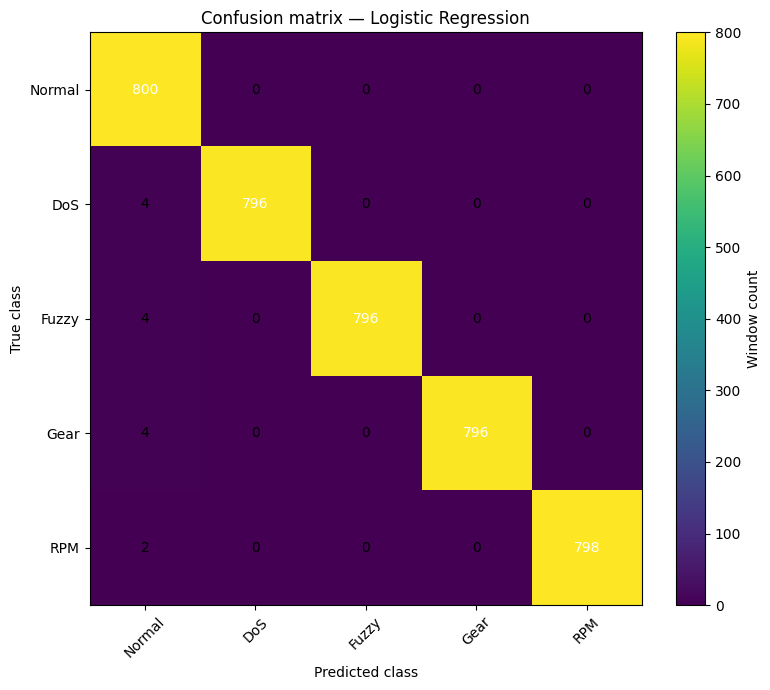

Saved image: /kaggle/working/autospectra_week04_outputs/plots/metrics_confusion_logistic_regression.png


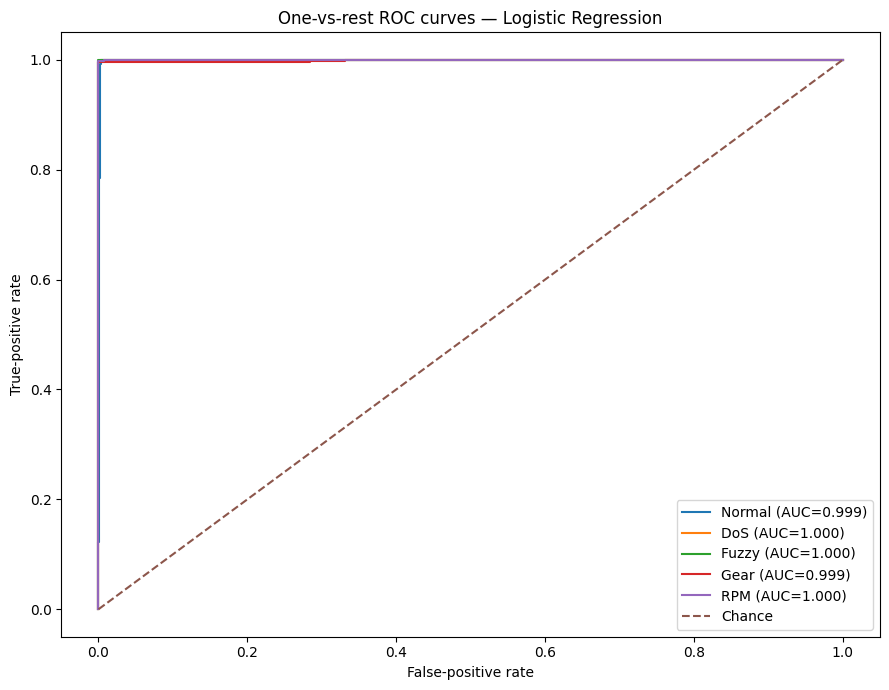

Saved image: /kaggle/working/autospectra_week04_outputs/plots/metrics_roc_logistic_regression.png


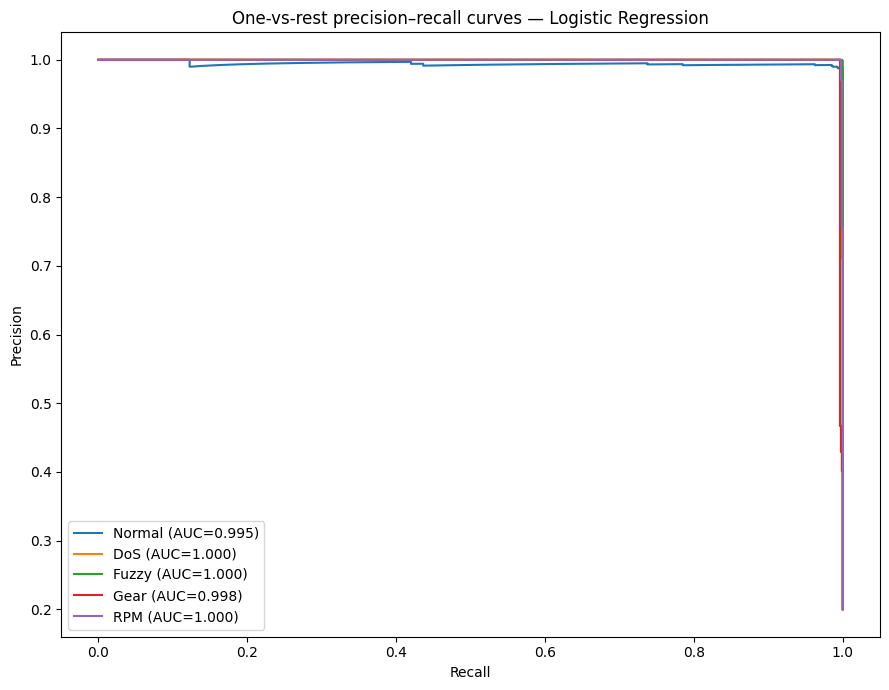

Saved image: /kaggle/working/autospectra_week04_outputs/plots/metrics_pr_logistic_regression.png


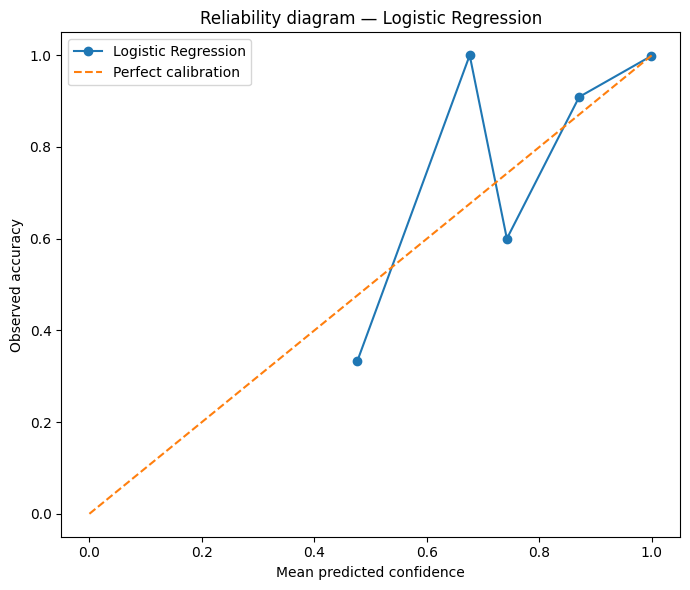

Saved image: /kaggle/working/autospectra_week04_outputs/plots/metrics_calibration_logistic_regression.png

Training: Random Forest

Random Forest
-------------


,Value
Model,Random Forest
Accuracy,0.99775
Balanced_Accuracy,0.99775
Macro_Precision,0.997775
Macro_Recall,0.99775
Macro_F1,0.997754
Weighted_F1,0.997754
MCC,0.997192
Log_Loss,0.033783
Macro_ROC_AUC_OVR,0.999475


,precision,recall,f1-score,support
Normal,0.988875,1.00000,0.994406,800.00000
DoS,1.000000,1.00000,1.000000,800.00000
Fuzzy,1.000000,0.99500,0.997494,800.00000
Gear,1.000000,0.99625,0.998121,800.00000
RPM,1.000000,0.99750,0.998748,800.00000
accuracy,0.997750,0.99775,0.997750,0.99775
macro avg,0.997775,0.99775,0.997754,4000.00000
weighted avg,0.997775,0.99775,0.997754,4000.00000


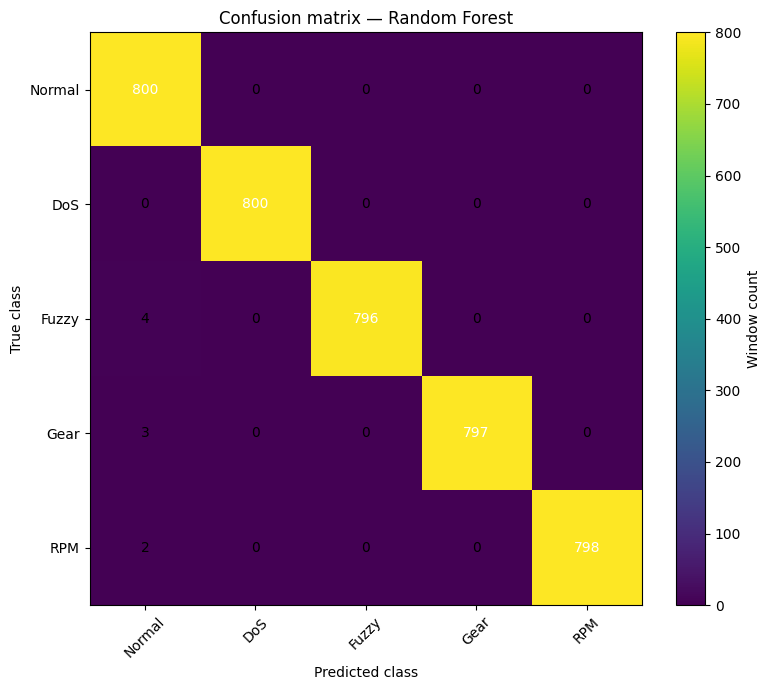

Saved image: /kaggle/working/autospectra_week04_outputs/plots/metrics_confusion_random_forest.png


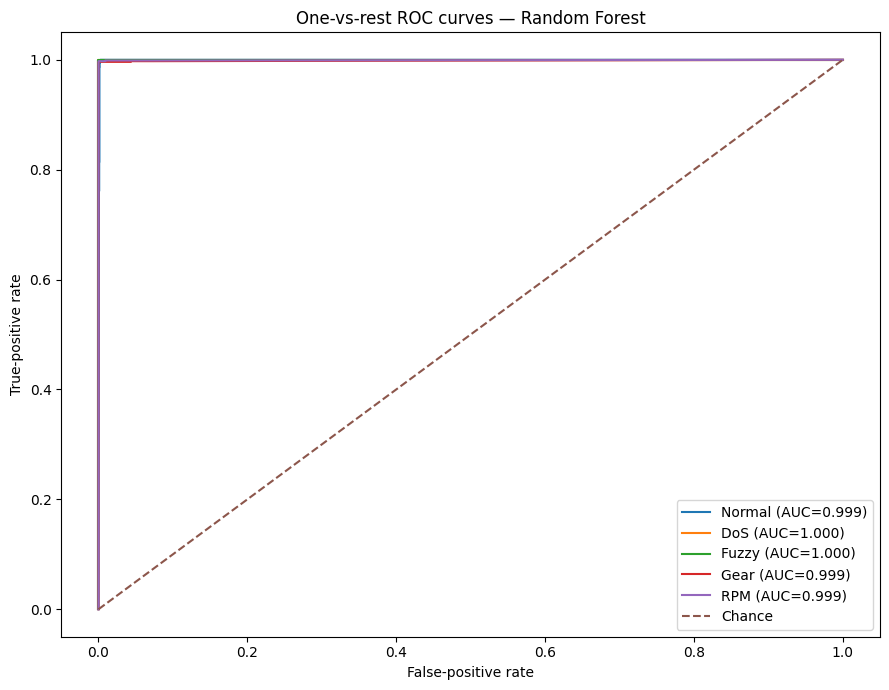

Saved image: /kaggle/working/autospectra_week04_outputs/plots/metrics_roc_random_forest.png


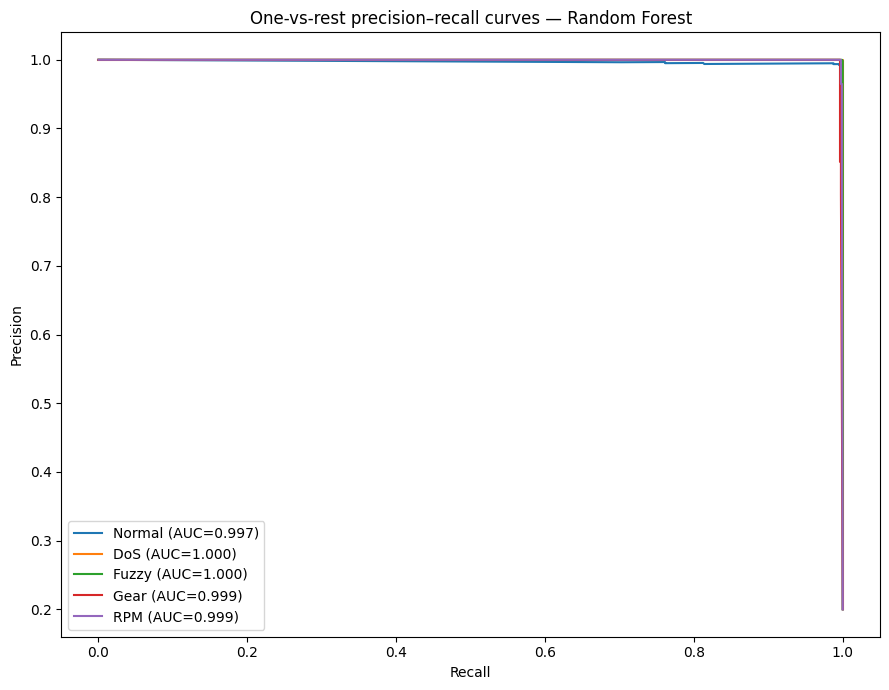

Saved image: /kaggle/working/autospectra_week04_outputs/plots/metrics_pr_random_forest.png


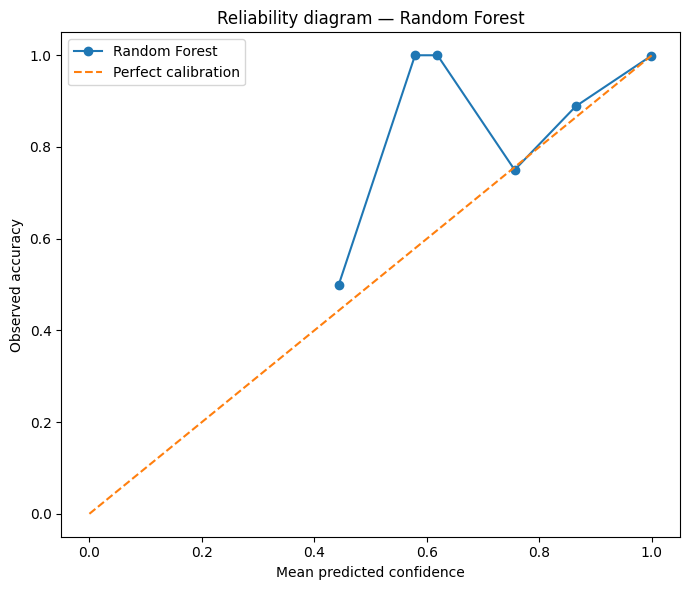

Saved image: /kaggle/working/autospectra_week04_outputs/plots/metrics_calibration_random_forest.png

Training: Extra Trees

Extra Trees
-----------


,Value
Model,Extra Trees
Accuracy,0.99725
Balanced_Accuracy,0.99725
Macro_Precision,0.997287
Macro_Recall,0.99725
Macro_F1,0.997256
Weighted_F1,0.997256
MCC,0.996569
Log_Loss,0.021083
Macro_ROC_AUC_OVR,0.999651


,precision,recall,f1-score,support
Normal,0.986436,1.00000,0.993172,800.00000
DoS,1.000000,0.99875,0.999375,800.00000
Fuzzy,1.000000,0.99500,0.997494,800.00000
Gear,1.000000,0.99500,0.997494,800.00000
RPM,1.000000,0.99750,0.998748,800.00000
accuracy,0.997250,0.99725,0.997250,0.99725
macro avg,0.997287,0.99725,0.997256,4000.00000
weighted avg,0.997287,0.99725,0.997256,4000.00000


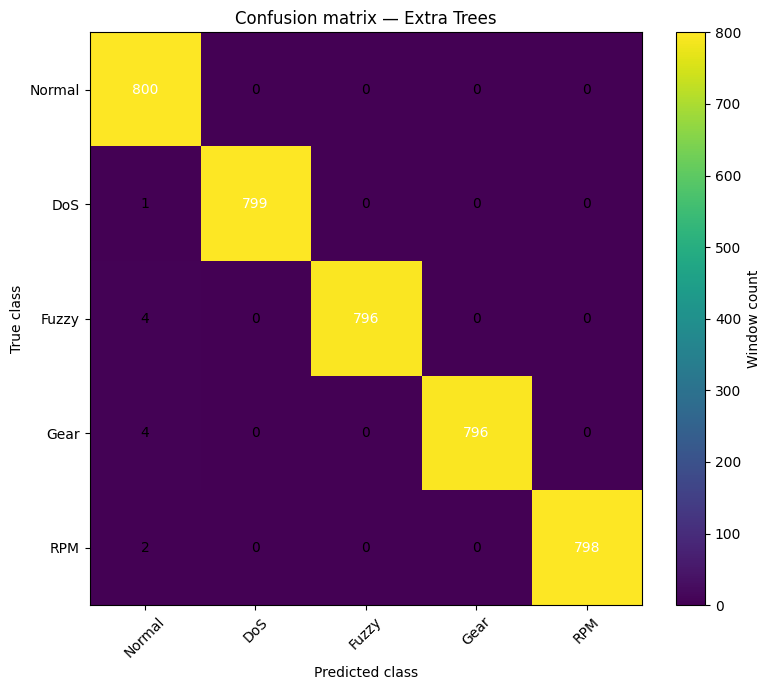

Saved image: /kaggle/working/autospectra_week04_outputs/plots/metrics_confusion_extra_trees.png


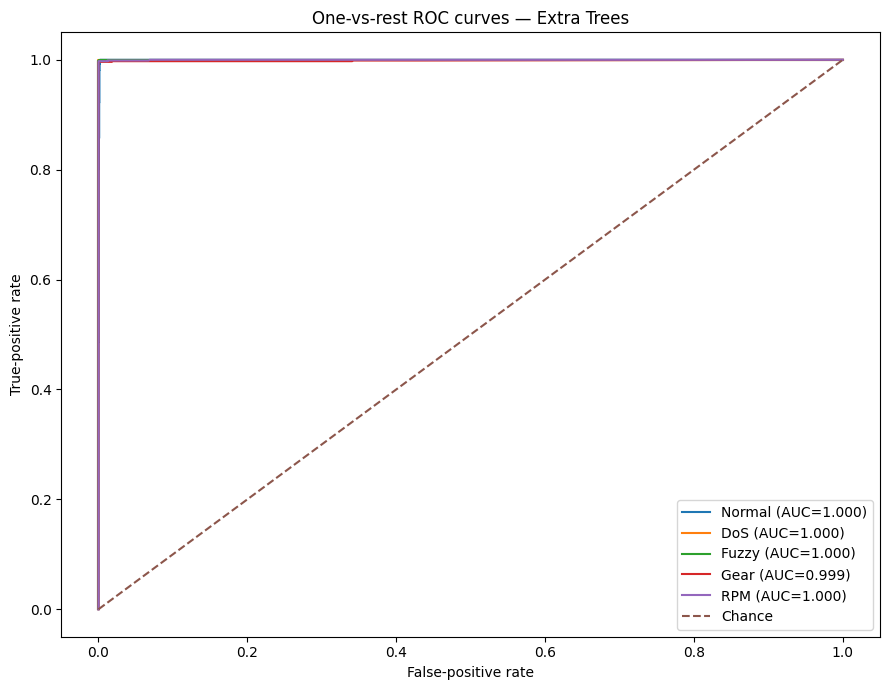

Saved image: /kaggle/working/autospectra_week04_outputs/plots/metrics_roc_extra_trees.png


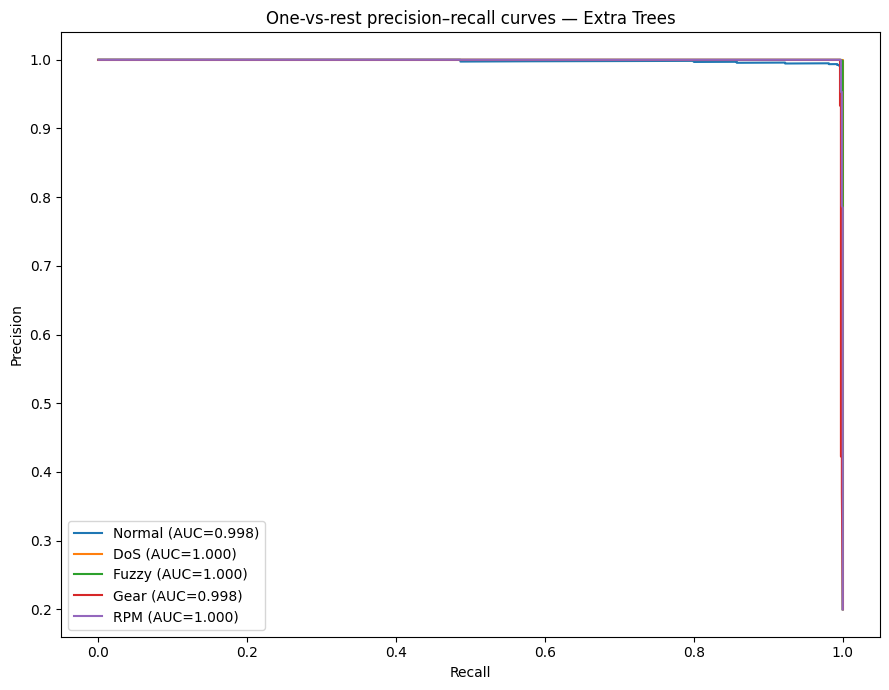

Saved image: /kaggle/working/autospectra_week04_outputs/plots/metrics_pr_extra_trees.png


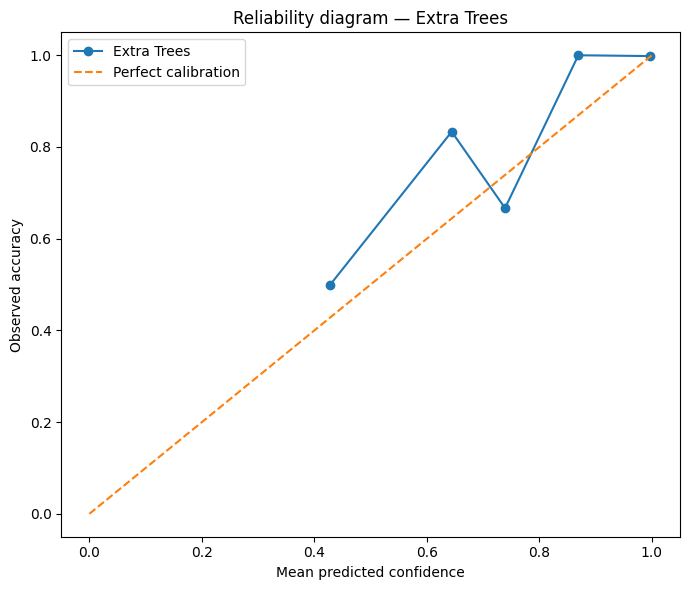

Saved image: /kaggle/working/autospectra_week04_outputs/plots/metrics_calibration_extra_trees.png

Training: XGBoost

XGBoost
-------


,Value
Model,XGBoost
Accuracy,0.99775
Balanced_Accuracy,0.99775
Macro_Precision,0.997775
Macro_Recall,0.99775
Macro_F1,0.997754
Weighted_F1,0.997754
MCC,0.997192
Log_Loss,0.012293
Macro_ROC_AUC_OVR,0.999828


,precision,recall,f1-score,support
Normal,0.988875,1.00000,0.994406,800.00000
DoS,1.000000,1.00000,1.000000,800.00000
Fuzzy,1.000000,0.99500,0.997494,800.00000
Gear,1.000000,0.99625,0.998121,800.00000
RPM,1.000000,0.99750,0.998748,800.00000
accuracy,0.997750,0.99775,0.997750,0.99775
macro avg,0.997775,0.99775,0.997754,4000.00000
weighted avg,0.997775,0.99775,0.997754,4000.00000


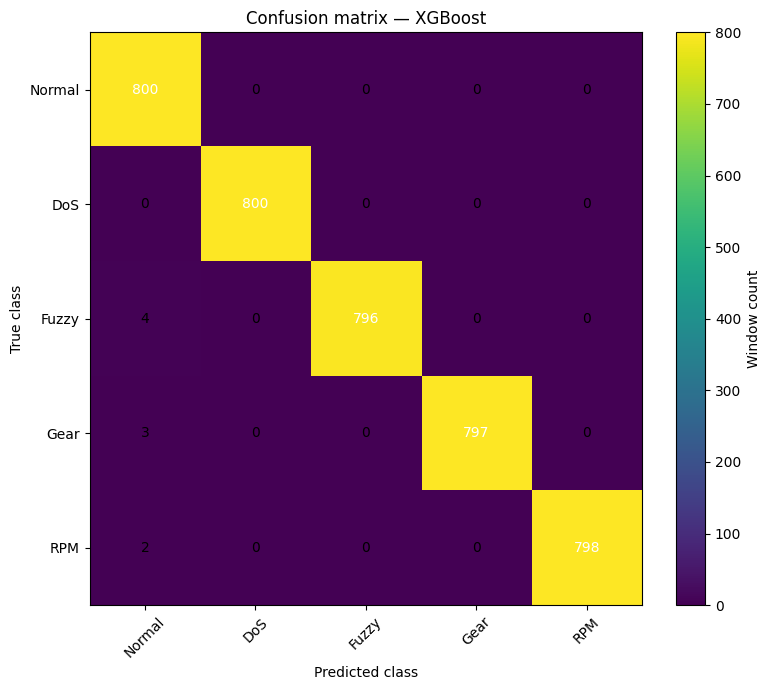

Saved image: /kaggle/working/autospectra_week04_outputs/plots/metrics_confusion_xgboost.png


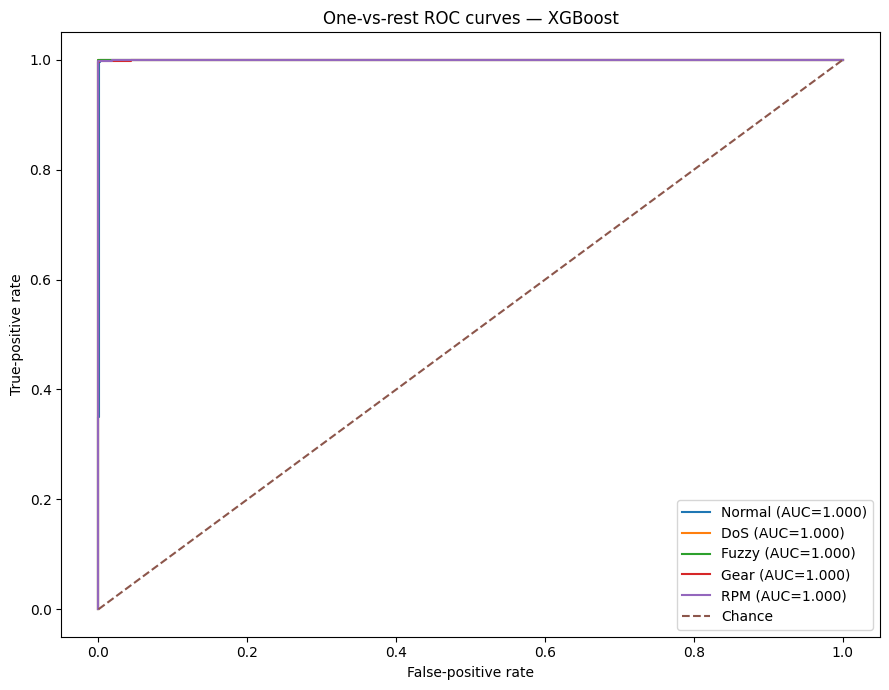

Saved image: /kaggle/working/autospectra_week04_outputs/plots/metrics_roc_xgboost.png


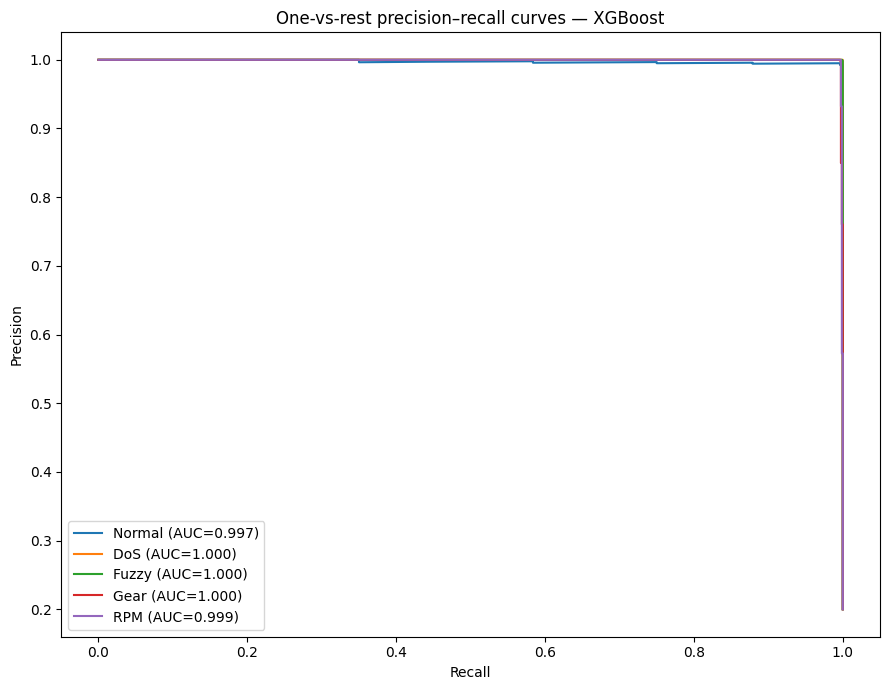

Saved image: /kaggle/working/autospectra_week04_outputs/plots/metrics_pr_xgboost.png


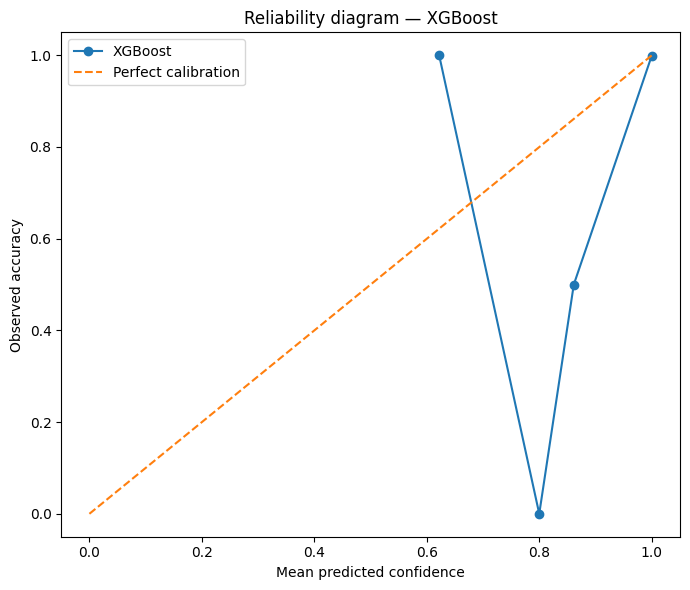

Saved image: /kaggle/working/autospectra_week04_outputs/plots/metrics_calibration_xgboost.png

Week 4 classical training complete.


In [12]:
# 7. Train and evaluate the Week 4 classical baselines

classical_models = {
    "Logistic Regression": Pipeline([
        (
            "scaler",
            StandardScaler(),
        ),
        (
            "classifier",
            LogisticRegression(
                max_iter=1_000,
                class_weight="balanced",
                solver="lbfgs",
                random_state=SEED,
            ),
        ),
    ]),
    "Random Forest": RandomForestClassifier(
        n_estimators=RF_TREES,
        min_samples_leaf=2,
        class_weight="balanced_subsample",
        random_state=SEED,
        n_jobs=-1,
    ),
    "Extra Trees": ExtraTreesClassifier(
        n_estimators=ET_TREES,
        min_samples_leaf=2,
        class_weight="balanced",
        random_state=SEED,
        n_jobs=-1,
    ),
}

if RUN_XGBOOST and XGBOOST_AVAILABLE:
    classical_models["XGBoost"] = XGBClassifier(
        n_estimators=XGB_TREES,
        max_depth=6,
        learning_rate=0.05,
        min_child_weight=2,
        subsample=0.85,
        colsample_bytree=0.85,
        reg_alpha=0.10,
        reg_lambda=2.0,
        gamma=0.0,
        objective="multi:softprob",
        num_class=len(CLASS_NAMES),
        eval_metric="mlogloss",
        tree_method="hist",
        random_state=SEED,
        n_jobs=-1,
    )
elif RUN_XGBOOST:
    print(
        "RUN_XGBOOST=True, but XGBoost could not be imported. "
        "Logistic Regression, Random Forest and Extra Trees will still run."
    )

classical_validation_probabilities = {}
classical_test_probabilities = {}

for model_name, model in classical_models.items():
    print("\n" + "=" * 90)
    print("Training:", model_name)
    print("=" * 90)

    fit_start = time.perf_counter()
    model.fit(X_train_tab, y_train)
    fit_seconds = time.perf_counter() - fit_start

    safe_name = (
        model_name.lower()
        .replace(" ", "_")
        .replace("+", "plus")
    )

    model_path = MODEL_DIR / f"{safe_name}.joblib"
    joblib.dump(model, model_path)

    validation_probabilities = model.predict_proba(
        X_validation_tab
    )
    classical_validation_probabilities[
        model_name
    ] = validation_probabilities

    inference_start = time.perf_counter()
    test_probabilities = model.predict_proba(
        X_test_tab
    )
    inference_seconds = (
        time.perf_counter()
        - inference_start
    )

    classical_test_probabilities[
        model_name
    ] = test_probabilities

    metric_row, _ = evaluate_and_store(
        model_name=model_name,
        y_true=y_test,
        probabilities=test_probabilities,
        inference_seconds=inference_seconds,
        model_path=model_path,
        make_all_plots=True,
    )

    metric_row["Training_Seconds"] = fit_seconds

gc.collect()

print("\nWeek 4 classical training complete.")

# Part B — Feature Importance

,Feature,Importance
0,dominant_id_norm,0.131709
1,id_entropy,0.087295
2,max_id_ratio,0.079569
3,payload_sum_mean,0.072686
4,payload_mean,0.067188
5,zero_id_ratio,0.064837
6,id_transition_rate,0.064477
7,payload_std,0.064047
8,payload_entropy,0.063848
9,unique_id_count,0.063702


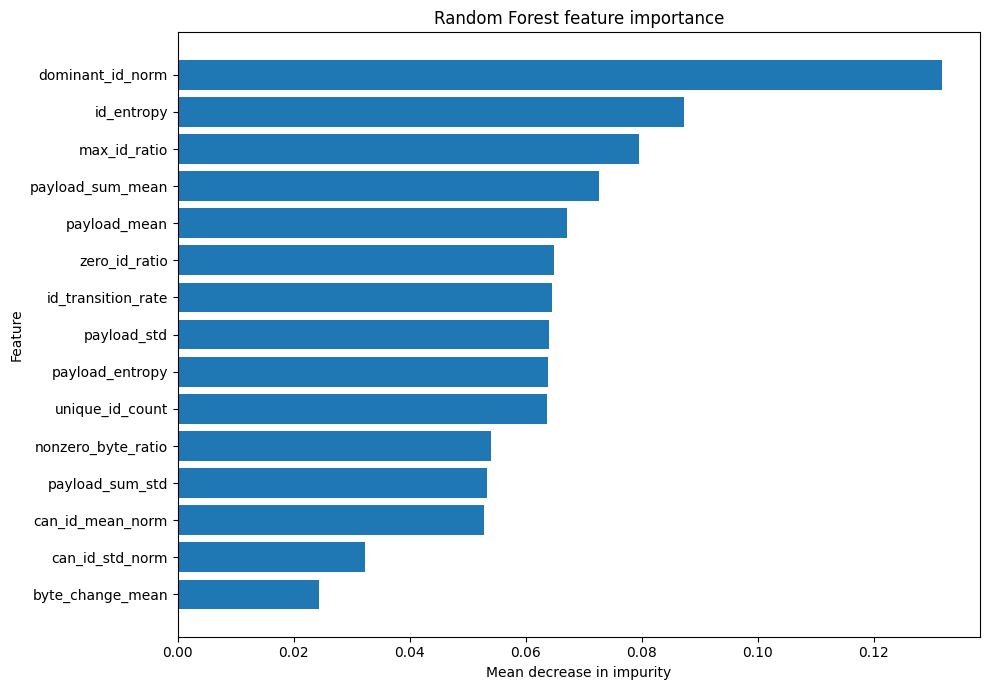

Saved image: /kaggle/working/autospectra_week04_outputs/plots/model_random_forest_feature_importance.png


In [13]:
# Random Forest feature importance
random_forest = classical_models[
    "Random Forest"
]

importance_df = (
    pd.DataFrame({
        "Feature": FEATURE_NAMES,
        "Importance":
            random_forest.feature_importances_,
    })
    .sort_values(
        "Importance",
        ascending=False,
    )
    .reset_index(drop=True)
)

display(importance_df)

plot_importance = (
    importance_df
    .head(15)
    .sort_values("Importance")
)

plt.figure(figsize=(10, 7))
plt.barh(
    plot_importance["Feature"],
    plot_importance["Importance"],
)
plt.title("Random Forest feature importance")
plt.xlabel("Mean decrease in impurity")
plt.ylabel("Feature")
save_current_figure(
    "model_random_forest_feature_importance.png"
)

# Part C — Classical Model Comparison

In [14]:
# 8. Build the Week 4 comparison table

test_support = (
    pd.Series(y_test)
    .value_counts()
    .reindex(
        range(len(CLASS_NAMES)),
        fill_value=0,
    )
)

if (test_support == 0).any():
    missing = [
        CLASS_NAMES[index]
        for index, count in test_support.items()
        if count == 0
    ]
    raise RuntimeError(
        "Cannot evaluate Week 4 baselines. "
        "Unseen test support is zero for: "
        + ", ".join(missing)
    )

evaluation_df = pd.DataFrame(evaluation_rows)

ordered_columns = [
    "Model",
    "Accuracy",
    "Balanced_Accuracy",
    "Macro_Precision",
    "Macro_Recall",
    "Macro_F1",
    "Weighted_F1",
    "MCC",
    "Macro_ROC_AUC_OVR",
    "Macro_PR_AUC",
    "Attack_FPR",
    "Attack_FNR",
    "ECE_10_bins",
    "Log_Loss",
    "Inference_ms_per_window",
    "Throughput_windows_per_second",
    "Model_Size_MB",
    "Training_Seconds",
]

evaluation_df = (
    evaluation_df[
        [
            column
            for column in ordered_columns
            if column in evaluation_df.columns
        ]
    ]
    .sort_values("Macro_F1", ascending=False)
    .reset_index(drop=True)
)

display(evaluation_df)

evaluation_df.to_csv(
    REPORT_DIR / "week04_classical_model_comparison.csv",
    index=False,
)

best_model_name = evaluation_df.iloc[0]["Model"]
best_macro_f1 = float(evaluation_df.iloc[0]["Macro_F1"])

print(
    f"Best Week 4 model by macro-F1: "
    f"{best_model_name} ({best_macro_f1:.6f})"
)

,Model,Accuracy,Balanced_Accuracy,Macro_Precision,Macro_Recall,Macro_F1,Weighted_F1,MCC,Macro_ROC_AUC_OVR,Macro_PR_AUC,Attack_FPR,Attack_FNR,ECE_10_bins,Log_Loss,Inference_ms_per_window,Throughput_windows_per_second,Model_Size_MB,Training_Seconds
0,Random Forest,0.99775,0.99775,0.997775,0.99775,0.997754,0.997754,0.997192,0.999475,0.998556,0.0,0.002812,0.000438,0.033783,0.024121,41457.081256,2.673676,3.932554
1,XGBoost,0.99775,0.99775,0.997775,0.99775,0.997754,0.997754,0.997192,0.999828,0.999278,0.0,0.002812,0.001758,0.012293,0.007687,130082.159567,1.257285,2.284711
2,Extra Trees,0.99725,0.99725,0.997287,0.99725,0.997256,0.997256,0.996569,0.999651,0.999272,0.0,0.003438,0.002360,0.021083,0.024295,41160.703012,8.566468,0.838194
3,Logistic Regression,0.99650,0.99650,0.996560,0.99650,0.996511,0.996511,0.995635,0.999544,0.998335,0.0,0.004375,0.000743,0.018683,0.001554,643296.043069,0.002824,0.426637


Best Week 4 model by macro-F1: Random Forest (0.997754)


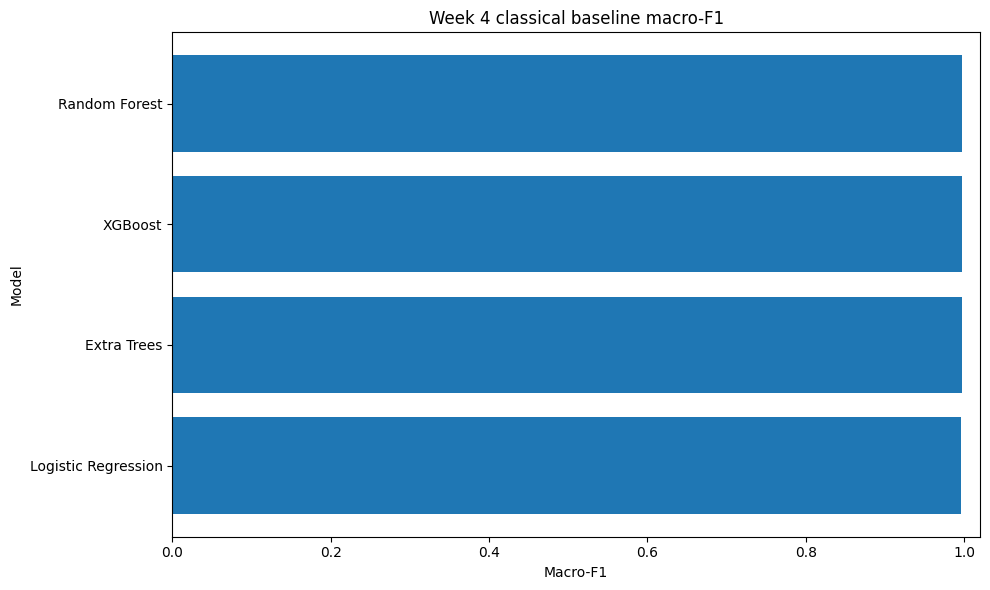

Saved image: /kaggle/working/autospectra_week04_outputs/plots/week04_macro_f1_comparison.png


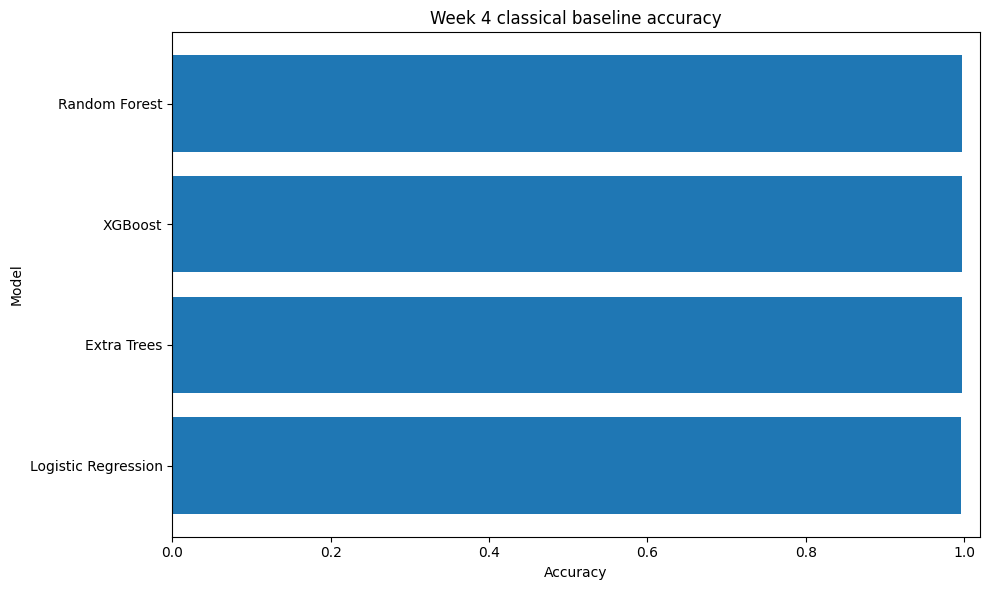

Saved image: /kaggle/working/autospectra_week04_outputs/plots/week04_accuracy_comparison.png


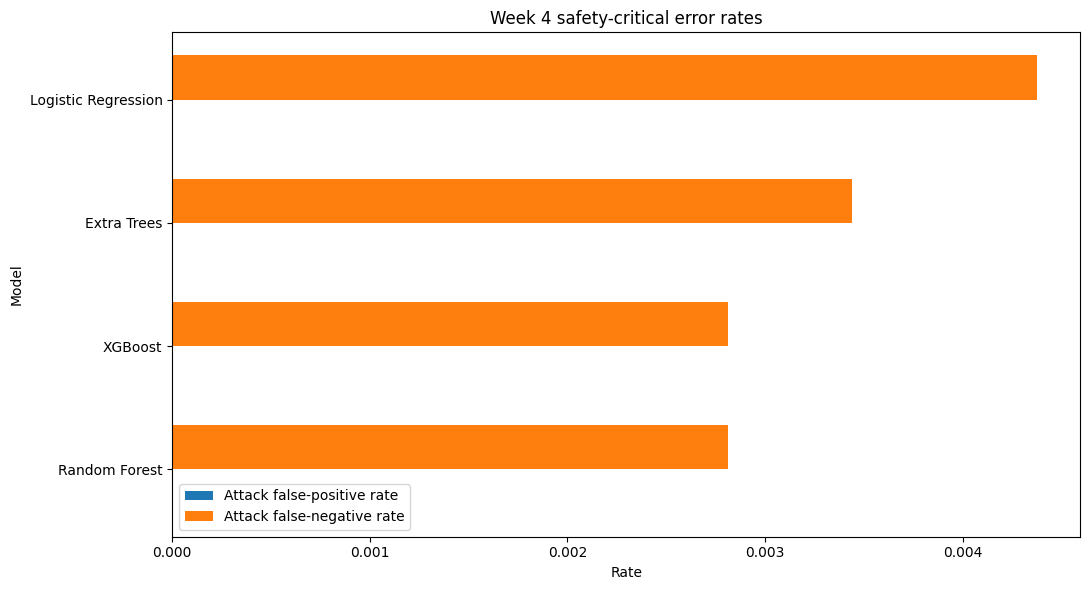

Saved image: /kaggle/working/autospectra_week04_outputs/plots/week04_attack_fpr_fnr.png


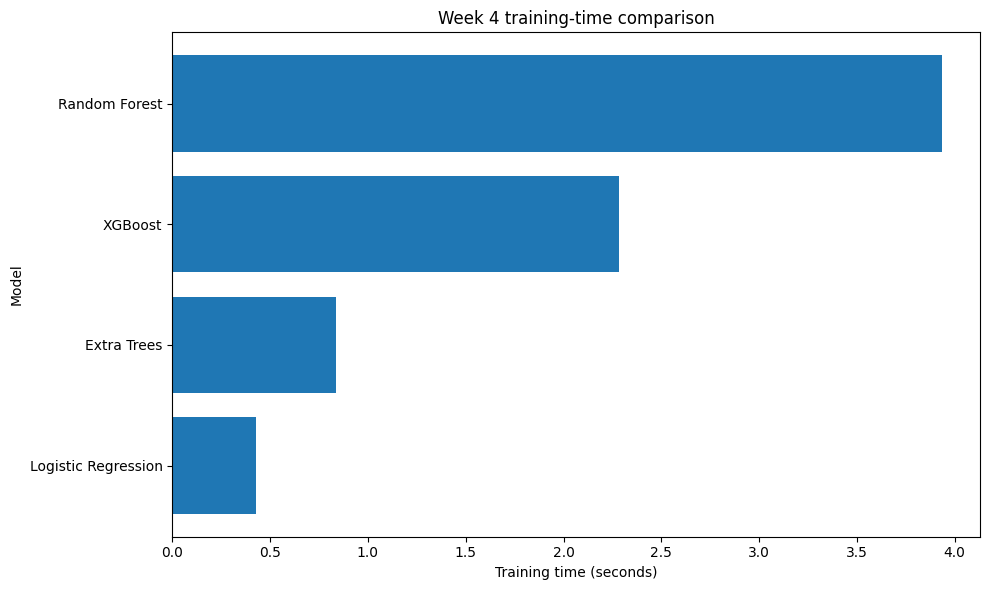

Saved image: /kaggle/working/autospectra_week04_outputs/plots/week04_training_time.png


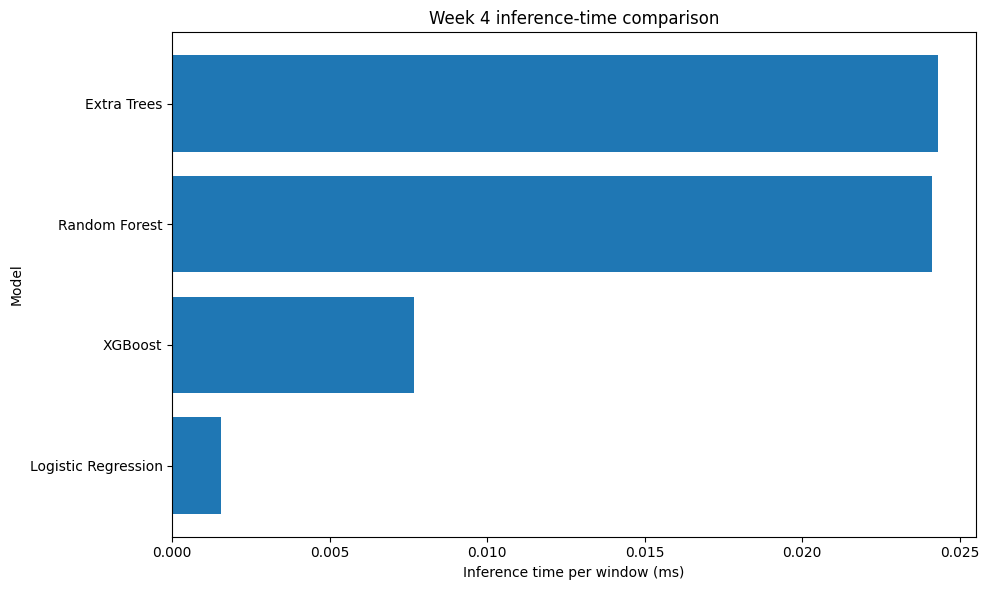

Saved image: /kaggle/working/autospectra_week04_outputs/plots/week04_inference_time.png


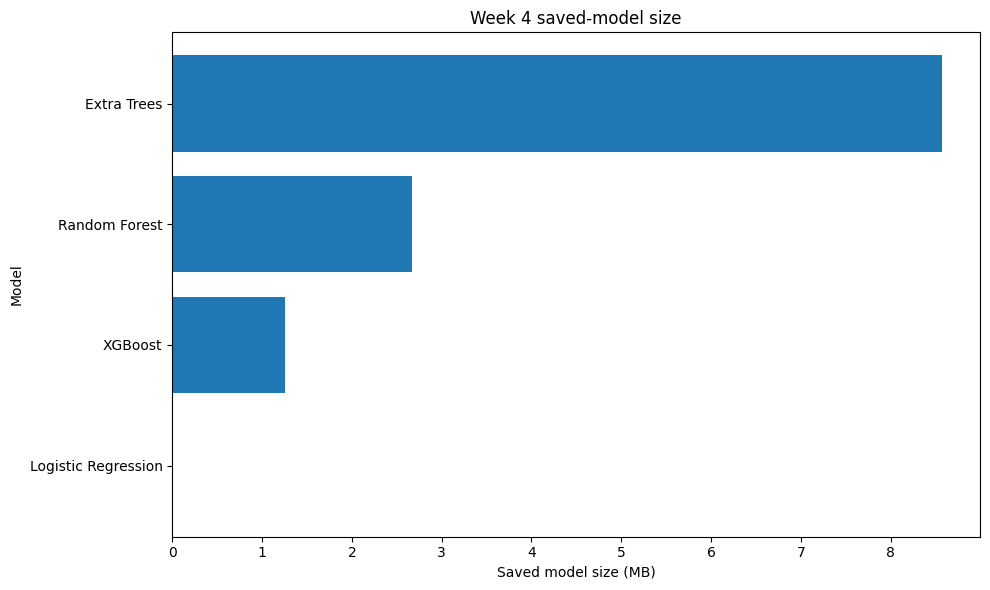

Saved image: /kaggle/working/autospectra_week04_outputs/plots/week04_model_size.png


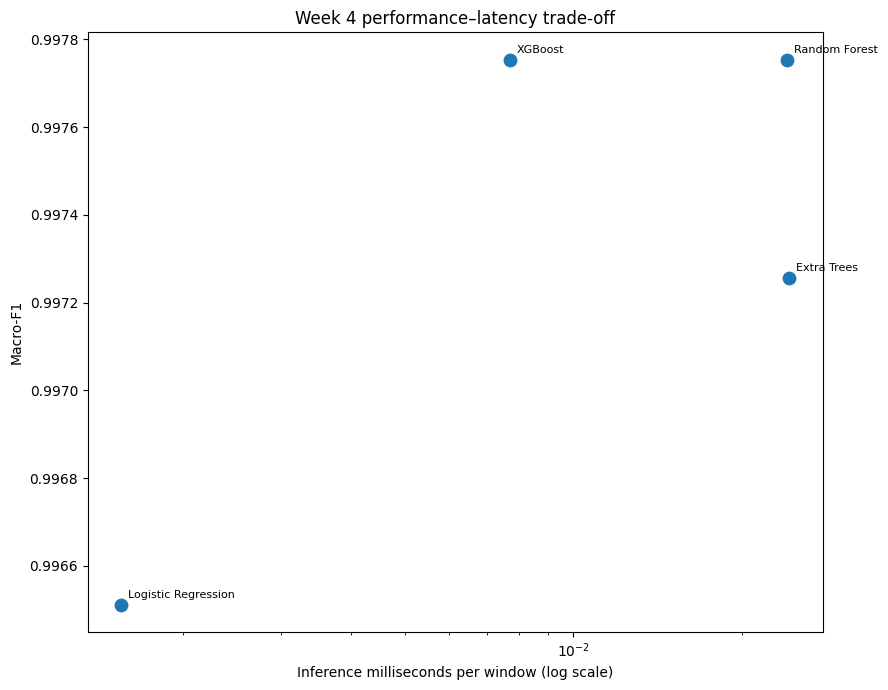

Saved image: /kaggle/working/autospectra_week04_outputs/plots/week04_performance_latency.png


In [15]:
# 9. Save comparison images

# Macro-F1
plot_df = evaluation_df.sort_values("Macro_F1")
plt.figure(figsize=(10, 6))
plt.barh(plot_df["Model"], plot_df["Macro_F1"])
plt.xlim(0, 1.02)
plt.title("Week 4 classical baseline macro-F1")
plt.xlabel("Macro-F1")
plt.ylabel("Model")
save_current_figure("week04_macro_f1_comparison.png")

# Accuracy
plot_df = evaluation_df.sort_values("Accuracy")
plt.figure(figsize=(10, 6))
plt.barh(plot_df["Model"], plot_df["Accuracy"])
plt.xlim(0, 1.02)
plt.title("Week 4 classical baseline accuracy")
plt.xlabel("Accuracy")
plt.ylabel("Model")
save_current_figure("week04_accuracy_comparison.png")

# Safety-critical FPR/FNR
plot_df = evaluation_df.sort_values("Attack_FNR")
positions = np.arange(len(plot_df))
width = 0.36

plt.figure(figsize=(11, 6))
plt.barh(
    positions - width / 2,
    plot_df["Attack_FPR"],
    height=width,
    label="Attack false-positive rate",
)
plt.barh(
    positions + width / 2,
    plot_df["Attack_FNR"],
    height=width,
    label="Attack false-negative rate",
)
plt.yticks(positions, plot_df["Model"])
plt.xlabel("Rate")
plt.ylabel("Model")
plt.title("Week 4 safety-critical error rates")
plt.legend()
save_current_figure("week04_attack_fpr_fnr.png")

# Training time
plot_df = evaluation_df.sort_values("Training_Seconds")
plt.figure(figsize=(10, 6))
plt.barh(plot_df["Model"], plot_df["Training_Seconds"])
plt.xlabel("Training time (seconds)")
plt.ylabel("Model")
plt.title("Week 4 training-time comparison")
save_current_figure("week04_training_time.png")

# Inference time
plot_df = evaluation_df.sort_values("Inference_ms_per_window")
plt.figure(figsize=(10, 6))
plt.barh(
    plot_df["Model"],
    plot_df["Inference_ms_per_window"],
)
plt.xlabel("Inference time per window (ms)")
plt.ylabel("Model")
plt.title("Week 4 inference-time comparison")
save_current_figure("week04_inference_time.png")

# Model size
plot_df = evaluation_df.sort_values("Model_Size_MB")
plt.figure(figsize=(10, 6))
plt.barh(plot_df["Model"], plot_df["Model_Size_MB"])
plt.xlabel("Saved model size (MB)")
plt.ylabel("Model")
plt.title("Week 4 saved-model size")
save_current_figure("week04_model_size.png")

# Performance-latency trade-off
plt.figure(figsize=(9, 7))
plt.scatter(
    evaluation_df["Inference_ms_per_window"],
    evaluation_df["Macro_F1"],
    s=80,
)
for _, row in evaluation_df.iterrows():
    plt.annotate(
        row["Model"],
        (
            row["Inference_ms_per_window"],
            row["Macro_F1"],
        ),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=8,
    )
plt.xscale("log")
plt.xlabel("Inference milliseconds per window (log scale)")
plt.ylabel("Macro-F1")
plt.title("Week 4 performance–latency trade-off")
save_current_figure("week04_performance_latency.png")

,Model,Class,Precision,Recall,F1,Support
0,Logistic Regression,Normal,0.982801,1.00000,0.991326,800
1,Logistic Regression,DoS,1.000000,0.99500,0.997494,800
2,Logistic Regression,Fuzzy,1.000000,0.99500,0.997494,800
3,Logistic Regression,Gear,1.000000,0.99500,0.997494,800
4,Logistic Regression,RPM,1.000000,0.99750,0.998748,800
5,Random Forest,Normal,0.988875,1.00000,0.994406,800
6,Random Forest,DoS,1.000000,1.00000,1.000000,800
7,Random Forest,Fuzzy,1.000000,0.99500,0.997494,800
8,Random Forest,Gear,1.000000,0.99625,0.998121,800
9,Random Forest,RPM,1.000000,0.99750,0.998748,800


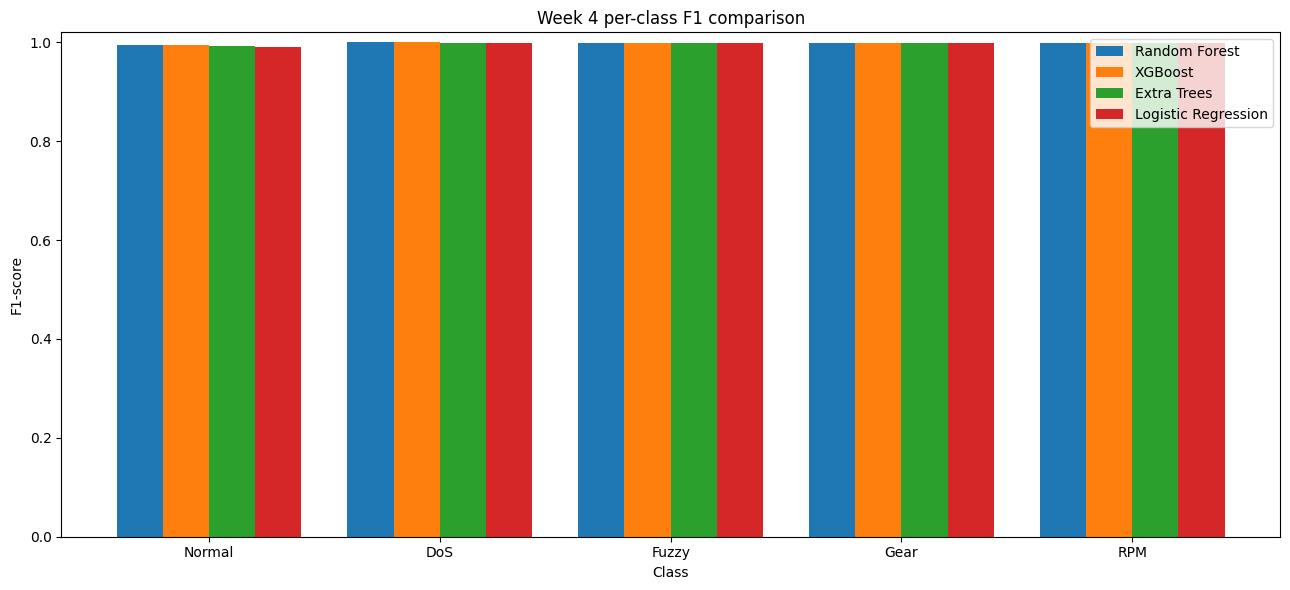

Saved image: /kaggle/working/autospectra_week04_outputs/plots/week04_per_class_f1.png


In [16]:
# 10. Per-class precision, recall and F1

per_class_rows = []

for model_name, stored in prediction_store.items():
    precision, recall, f1_values, support = (
        precision_recall_fscore_support(
            y_test,
            stored["predictions"],
            labels=np.arange(len(CLASS_NAMES)),
            zero_division=0,
        )
    )

    for class_index, class_name in enumerate(CLASS_NAMES):
        per_class_rows.append({
            "Model": model_name,
            "Class": class_name,
            "Precision": precision[class_index],
            "Recall": recall[class_index],
            "F1": f1_values[class_index],
            "Support": int(support[class_index]),
        })

per_class_df = pd.DataFrame(per_class_rows)
display(per_class_df)

per_class_df.to_csv(
    REPORT_DIR / "week04_per_class_metrics.csv",
    index=False,
)

# One combined per-class F1 comparison.
model_order = evaluation_df["Model"].tolist()
x = np.arange(len(CLASS_NAMES))
bar_width = 0.8 / max(len(model_order), 1)

plt.figure(figsize=(13, 6))

for model_index, model_name in enumerate(model_order):
    values = (
        per_class_df[
            per_class_df["Model"] == model_name
        ]
        .set_index("Class")
        .reindex(CLASS_NAMES)["F1"]
        .to_numpy()
    )

    plt.bar(
        x + model_index * bar_width,
        values,
        width=bar_width,
        label=model_name,
    )

plt.xticks(
    x + bar_width * (len(model_order) - 1) / 2,
    CLASS_NAMES,
)
plt.ylim(0, 1.02)
plt.xlabel("Class")
plt.ylabel("F1-score")
plt.title("Week 4 per-class F1 comparison")
plt.legend()
save_current_figure("week04_per_class_f1.png")

# Part D — Critical Interpretation

High accuracy is not sufficient for a safety-related intrusion-detection system. Week 4 therefore focuses on:

- **Macro-F1:** equal contribution from all five classes.
- **Attack FNR:** attacks incorrectly classified as Normal.
- **Attack FPR:** Normal windows incorrectly flagged as attacks.
- **Per-class recall:** whether a particular attack type is missed.
- **Calibration:** whether confidence reflects empirical correctness.
- **Inference time:** whether the model is suitable for a responsive prototype.
- **Model size:** whether the baseline is lightweight enough for deployment experiments.

Near-perfect results must be interpreted cautiously. The HCRL benchmark represents one vehicle platform, the experiment uses balanced samples, and CAN identifiers may provide dataset-specific shortcuts. Week 4 results therefore demonstrate benchmark performance, not universal vehicle generalisation.

In [17]:
# 11. Export Week 4 reports, image manifest and ZIP files

# Random Forest feature importance CSV
importance_df.to_csv(
    REPORT_DIR / "week04_random_forest_feature_importance.csv",
    index=False,
)

# Prediction summary
prediction_summary_rows = []

for model_name, stored in prediction_store.items():
    prediction_summary_rows.append({
        "Model": model_name,
        "Predicted_Windows": int(len(stored["predictions"])),
        "Probability_Rows": int(stored["probabilities"].shape[0]),
        "Probability_Columns": int(stored["probabilities"].shape[1]),
    })

prediction_summary_df = pd.DataFrame(prediction_summary_rows)
prediction_summary_df.to_csv(
    REPORT_DIR / "week04_prediction_shapes.csv",
    index=False,
)

week4_summary = {
    "project": "AutoSPECTRA",
    "week": 4,
    "scope": "Classical machine-learning baselines and evaluation",
    "models": list(classical_models.keys()),
    "classes": CLASS_NAMES,
    "feature_count": len(FEATURE_NAMES),
    "window_size": WINDOW_SIZE,
    "stride": STRIDE,
    "split_strategy": SPLIT_STRATEGY,
    "best_model_by_macro_f1": str(best_model_name),
    "best_macro_f1": best_macro_f1,
    "test_support": {
        CLASS_NAMES[index]: int(count)
        for index, count in test_support.items()
    },
    "deep_learning_trained": False,
    "fusion_performed": False,
    "next_week": "Recurrence-image encoder and CNN training",
}

with (
    REPORT_DIR / "week04_summary.json"
).open("w", encoding="utf-8") as handle:
    json.dump(week4_summary, handle, indent=2)

# Image manifest
image_files = sorted(PLOT_DIR.glob("*.png"))
image_manifest = pd.DataFrame([
    {
        "Image": path.name,
        "Size_KB": round(path.stat().st_size / 1024, 2),
        "Kaggle_Path": str(path),
    }
    for path in image_files
])

display(image_manifest)

image_manifest.to_csv(
    REPORT_DIR / "week04_image_manifest.csv",
    index=False,
)

# ZIP containing ONLY figures
images_zip = Path(
    "/kaggle/working/AutoSPECTRA_Week04_Images.zip"
)

with zipfile.ZipFile(
    images_zip,
    "w",
    zipfile.ZIP_DEFLATED,
) as archive:
    for path in image_files:
        archive.write(
            path,
            arcname=path.name,
        )

# Evidence ZIP: reports + plots, but no trained model binaries.
evidence_zip = Path(
    "/kaggle/working/AutoSPECTRA_Week04_Evidence.zip"
)

with zipfile.ZipFile(
    evidence_zip,
    "w",
    zipfile.ZIP_DEFLATED,
) as archive:
    for directory in [REPORT_DIR, PLOT_DIR]:
        for path in directory.rglob("*"):
            if path.is_file():
                archive.write(
                    path,
                    arcname=path.relative_to(OUTPUT_DIR),
                )

print("=" * 90)
print("AUTOSPECTRA WEEK 4 COMPLETE")
print("=" * 90)
print("Models trained:", list(classical_models.keys()))
print("Best model by macro-F1:", best_model_name)
print("Images saved:", len(image_files))
print("Plots folder:", PLOT_DIR)
print("Images ZIP:", images_zip)
print("Evidence ZIP:", evidence_zip)

print("\nSaved images:")
for path in image_files:
    print(" -", path.name)

,Image,Size_KB,Kaggle_Path
0,metrics_calibration_extra_trees.png,89.42,/kaggle/working/autospectra_week04_outputs/plo...
1,metrics_calibration_logistic_regression.png,99.92,/kaggle/working/autospectra_week04_outputs/plo...
2,metrics_calibration_random_forest.png,90.39,/kaggle/working/autospectra_week04_outputs/plo...
3,metrics_calibration_xgboost.png,98.82,/kaggle/working/autospectra_week04_outputs/plo...
4,metrics_confusion_extra_trees.png,90.03,/kaggle/working/autospectra_week04_outputs/plo...
5,metrics_confusion_logistic_regression.png,92.88,/kaggle/working/autospectra_week04_outputs/plo...
6,metrics_confusion_random_forest.png,90.63,/kaggle/working/autospectra_week04_outputs/plo...
7,metrics_confusion_xgboost.png,90.47,/kaggle/working/autospectra_week04_outputs/plo...
8,metrics_pr_extra_trees.png,81.21,/kaggle/working/autospectra_week04_outputs/plo...
9,metrics_pr_logistic_regression.png,84.37,/kaggle/working/autospectra_week04_outputs/plo...


AUTOSPECTRA WEEK 4 COMPLETE
Models trained: ['Logistic Regression', 'Random Forest', 'Extra Trees', 'XGBoost']
Best model by macro-F1: Random Forest
Images saved: 25
Plots folder: /kaggle/working/autospectra_week04_outputs/plots
Images ZIP: /kaggle/working/AutoSPECTRA_Week04_Images.zip
Evidence ZIP: /kaggle/working/AutoSPECTRA_Week04_Evidence.zip

Saved images:
 - metrics_calibration_extra_trees.png
 - metrics_calibration_logistic_regression.png
 - metrics_calibration_random_forest.png
 - metrics_calibration_xgboost.png
 - metrics_confusion_extra_trees.png
 - metrics_confusion_logistic_regression.png
 - metrics_confusion_random_forest.png
 - metrics_confusion_xgboost.png
 - metrics_pr_extra_trees.png
 - metrics_pr_logistic_regression.png
 - metrics_pr_random_forest.png
 - metrics_pr_xgboost.png
 - metrics_roc_extra_trees.png
 - metrics_roc_logistic_regression.png
 - metrics_roc_random_forest.png
 - metrics_roc_xgboost.png
 - model_random_forest_feature_importance.png
 - week04_accuracy

# Week 4 Completion Summary

## Completed

- Protected Week 3 train/validation/test data reused.
- 24 engineered tabular features used.
- Logistic Regression trained and evaluated.
- Random Forest trained and evaluated.
- Extra Trees trained and evaluated.
- XGBoost trained when the package is available.
- Confusion matrices saved for every model.
- ROC curves saved for every model.
- Precision–recall curves saved for every model.
- Reliability diagrams saved for every model.
- Random Forest feature importance saved.
- Macro-F1, accuracy, FPR/FNR, training time, inference time, model size and performance-latency comparison figures saved.
- Per-class metrics exported.
- Image manifest exported.
- Separate image-only and evidence ZIP files created.

## Kaggle Downloads

After the notebook finishes, download:

```text
/kaggle/working/AutoSPECTRA_Week04_Images.zip
/kaggle/working/AutoSPECTRA_Week04_Evidence.zip
```

## GitHub Image Folder

After downloading and extracting the image ZIP, selected Week 4 images can be committed to:

```text
results/week04/plots/
```

Do not commit trained `.joblib` model files unless the group explicitly decides they are small enough and required. GitHub evidence is adequately supported by the notebook, CSV/JSON metrics and selected PNG figures.

## Week 5 Handover

Week 5 will introduce the recurrence-image CNN. It should use the same protected split so that its results are directly comparable with these Week 4 baselines.